# WQ Quark-Only 1M Scan — Exploratory Plots

This notebook builds **clear, well-labeled** exploratory figures from the completed
**1,000,000-point RS quark-only flavor scan**
(`scan_outputs/wq_quarkonly_1M_full/`). It supersedes the auto-generated plots in
`analysis/plots/` (which were not legible enough).

**Three deliverables:**
- **A.** The actual values inside the quark Yukawas (all 9 entries of `Y_u`, `Y_d`).
- **B.** Bulk localization masses `c_Q`, `c_u`, `c_d` (geometric localization).
- **C.** The constraint-carving plot — `M_KK` vs a structural axis `X`, showing how
  the ~40 quark-only constraints work toward raising `M_KK`.

## Hard ground rules enforced throughout
1. **`M_KK ≥ 4 TeV` everywhere.** The 1/2/3 TeV tiles are **dropped**; we use only
   `M_KK ∈ {5, 7, 10, 15, 20, 30, 50} TeV` and all `M_KK` axes are floored at 4 TeV.
2. **Scales are never silently mixed.** Every distribution / curve is grouped by an
   **exact** `(quark_fit_r, M_KK)` cell or faceted by one of them. The scale is labeled
   on every panel.
3. **These are QUARK-ONLY constraints.** The lepton sector is **dropped and is NOT yet
   rigorous**. The 37 allowlisted constraints are enumerated below and color-coded
   **rigorous / proxy / partial** consistently across all plots, using the **per-row
   `tag`** field (not hardcoded).

In [1]:
import os
import sys

# Make the repo root importable (notebook runs with cwd = notebooks/).
_REPO_ROOT = "/n/holylabs/randall_lab/Lab/obarrera/5D-Neutrino-Mixing"
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Large, legible defaults
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "axes.titleweight": "bold",
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

SCAN_ROOT = os.path.abspath(
    os.path.join(os.getcwd(), "..", "scan_outputs", "wq_quarkonly_1M_full")
)
if not os.path.isdir(SCAN_ROOT):
    # fall back to absolute repo path if cwd is elsewhere
    SCAN_ROOT = "/n/holylabs/randall_lab/Lab/obarrera/5D-Neutrino-Mixing/scan_outputs/wq_quarkonly_1M_full"
CACHE = os.path.join(SCAN_ROOT, "wq_quarkonly_cache.parquet")
SUBSAMPLE = os.path.join(SCAN_ROOT, "wq_quarkonly_fitted_subsample.parquet")
FIGDIR = os.path.abspath(os.path.join(os.getcwd(), "figs"))
if not os.path.basename(os.getcwd()) == "notebooks":
    FIGDIR = "/n/holylabs/randall_lab/Lab/obarrera/5D-Neutrino-Mixing/notebooks/figs"
os.makedirs(FIGDIR, exist_ok=True)
print("scan root :", SCAN_ROOT)
print("cache     :", CACHE)
print("fig dir   :", FIGDIR)

scan root : /n/holylabs/randall_lab/Lab/obarrera/5D-Neutrino-Mixing/scan_outputs/wq_quarkonly_1M_full
cache     : /n/holylabs/randall_lab/Lab/obarrera/5D-Neutrino-Mixing/scan_outputs/wq_quarkonly_1M_full/wq_quarkonly_cache.parquet
fig dir   : /n/holylabs/randall_lab/Lab/obarrera/5D-Neutrino-Mixing/notebooks/figs


## The 37 quark-only allowlisted constraints

Physics names are read live from `flavor_catalog_constraints.registry` (each
constraint's `.observable`). The **rigorous / proxy / partial** split is taken from
the **per-row `tag`** stored in the scan output (verified below), *not* hardcoded.

**Honest scope statement:**
- **Lepton sector is DROPPED** and is **NOT yet fully rigorous** — this is a
  quark-only study.
- **ΔF=2 meson mixing (rigorous):** `K001` ε_K, `K002` Δm_K, `B001` Δm_d,
  `B003` Δm_s, `C001` D-mixing, plus the rigorous mixing-phase observables.
  Their experimental reach is **~1–3 TeV**, so above 4 TeV they are already satisfied.
- **Radiative / oblique / collider (proxy):** `B011–B014` b→sγ family, `EW001`
  oblique S,T,U, top-FCNC `T003–T008`. These are **documented proxies**, not full RS
  loop matchings. The longest proxy reach is **~7 TeV** (EW001 / B012).
- **Nonleptonic & EDM (partial):** `B032–B034`, `K003/K013`, `C003`, `E004–E009`,
  `EW003` — flagged `NEEDS-HUMAN-PHYSICS` (no first-principles SM/RS prediction yet);
  they are carried as advisory and do **not** veto.

In [2]:
from flavor_catalog_constraints.registry import discover, get
discover()

ALLOWLIST = [
    "K001","K002","B001","B002","B003","B004","C001","C002","B011","B012","B013",
    "B014","B032","B033","B034","C003","K003","K013","T001","T002","T003","T004",
    "T005","T006","T007","T008","T010","T011","T012","T014","EW001","EW003",
    "E004","E006","E007","E008","E009",
]

OBSERVABLE = {}
for cid in ALLOWLIST:
    c = get(cid)
    OBSERVABLE[cid] = getattr(c, "observable", cid) if c is not None else cid

# Consistent tag colors used in EVERY plot.
TAG_COLOR = {"rigorous": "#1b7837", "proxy": "#2166ac", "partial": "#b2182b"}
TAG_LABEL = {"rigorous": "rigorous (ΔF=2 etc.)",
             "proxy": "proxy (oblique/radiative/collider)",
             "partial": "partial (NEEDS-HUMAN-PHYSICS)"}

## Load the cached DataFrame (1M rows)

The 1M rows are loaded **once** into a flat parquet cache
(`wq_quarkonly_cache.parquet`, built by `_build_cache.py`, which is read-only on the
scan). Columns include params (`M_KK`, `r`, …), `fit_diagnostics`
(`cQ1..3`, `cu1..3`, `cd1..3`, `up_sv*`, `dn_sv*`, `max_abs_quark_yukawa`), the
**anarchic INPUT** Yukawa magnitudes `Yu_ij` / `Yd_ij`, the survival flags, and per
constraint `{__pass, __ratio, __tag, __active, __eval, __sev}`.

In [3]:
df = pd.read_parquet(CACHE)
print("loaded cache:", df.shape)

# Per-id tag table, read from the data (modal tag over evaluated rows).
def modal_tag(cid):
    s = df[f"{cid}__tag"]
    s = s[s.astype(str) != ""]
    return s.mode().iloc[0] if len(s) else "partial"

TAG = {cid: modal_tag(cid) for cid in ALLOWLIST}

tag_table = pd.DataFrame({
    "id": ALLOWLIST,
    "observable": [OBSERVABLE[c] for c in ALLOWLIST],
    "tag": [TAG[c] for c in ALLOWLIST],
})
for t in ("rigorous", "proxy", "partial"):
    ids = tag_table.loc[tag_table.tag == t, "id"].tolist()
    print(f"\n[{t}]  ({len(ids)})")
    for cid in ids:
        print(f"   {cid:6s}  {OBSERVABLE[cid]}")

loaded cache: (1000000, 267)



[rigorous]  (9)
   K001    epsilon_K
   K002    Delta m_K
   B001    Delta m_d
   B002    S_psiK_S
   B003    Delta m_s
   B004    phi_s(B_s -> J/psi phi)
   C001    D0-D0bar mixing
   T012    max Zcc pull from R_c^0 and A_c
   T014    max BR(Z -> bs, bd, sd) down-sector FCNC

[proxy]  (12)
   C002    D0-D0bar indirect CP violation
   B011    BR(Bbar -> X_s gamma)
   B012    BR(B0 -> K*(892)0 gamma)
   B013    BR(B_s0 -> phi(1020) gamma)
   B014    BR(B+ -> rho+ gamma), BR(B0 -> rho0/omega gamma)
   T003    BR(t -> c gamma)
   T004    BR(t -> u gamma)
   T005    BR(t -> c g)
   T006    BR(t -> u g)
   T007    BR(t -> H c)
   T008    BR(t -> H u)
   EW001   S,T,U oblique electroweak parameters

[partial]  (16)
   B032    Delta A_CP(B -> K pi)
   B033    S_phiK_S
   B034    phi_s^sss(Bs -> phi phi)
   C003    Delta A_CP(D0 -> K+K-, pi+pi-)
   K003    Re(epsilon'/epsilon)
   K013    BR(K_L -> pi0 gamma gamma)
   T001    BR(t -> c Z)
   T002    BR(t -> u Z)
   T010    max Zbb pull from R_

### Apply the M_KK ≥ 4 TeV cut and define the analysis frame

We keep `M_KK ∈ {5,7,10,15,20,30,50} TeV` and **drop skipped rows** (failed fit /
perturbativity gate) for all rate/distribution work. The full frame is kept only for
bookkeeping.

In [4]:
MKK_KEEP = [5000.0, 7000.0, 10000.0, 15000.0, 20000.0, 30000.0, 50000.0]
R_VALS = sorted(df["r"].unique())
MKK_TEV = [m / 1000.0 for m in MKK_KEEP]

mask = df["M_KK"].isin(MKK_KEEP) & (~df["skipped"])
d = df.loc[mask].copy()
print("rows after M_KK>=4TeV + drop-skipped:", len(d))
print("r values   :", R_VALS)
print("M_KK [TeV] :", MKK_TEV)
print("\nevaluated rows per (r, M_KK[TeV]):")
print(d.groupby(["r", d["M_KK"] / 1000]).size().unstack().astype("Int64"))

rows after M_KK>=4TeV + drop-skipped: 614219
r values   : [np.float64(0.05), np.float64(0.1), np.float64(0.25), np.float64(0.5), np.float64(1.0)]
M_KK [TeV] : [5.0, 7.0, 10.0, 15.0, 20.0, 30.0, 50.0]

evaluated rows per (r, M_KK[TeV]):
M_KK   5.0    7.0    10.0   15.0   20.0   30.0   50.0
r                                                    
0.05   9753   9728   9661   9494   9518   9551   9382
0.10  18231  18215  18212  18211  18206  18145  18049
0.25  19999  19996  19997  19995  19998  19989  19995
0.50  19998  19992  19992  19992  19991  19994  19994
1.00  19991  19993  19993  19990  19992  19992  19990


# Plot A — The 9 Yukawa entries

**Design decision (documented).** "The actual values inside the Yukawas" can mean two
different matrices:

- **INPUT / seed (anarchic):** the O(1) complex matrix *drawn* before the fit. Stored
  in full in every row (`quark_yukawa_seed`). This is the *prior*, identical in
  distribution across `r` and `M_KK` by construction.
- **Fitted / physical:** the 3×3 dimensionless Yukawa `result.point.Y_u/Y_d` that
  actually enters the RS observables after the geometry fit to PDG masses + CKM. Only
  its **singular values** are serialized; the full 3×3 is **not**.

The physically meaningful object for "what the Yukawas look like in the model" is the
**fitted/physical** one — its structure (texture, hierarchy) is what the constraints
see. We therefore **recompute the fitted 3×3 for a stratified subsample** by re-running
`quarkConstraints.fit.fit_quark_sector` exactly as the producer did (deterministic from
seed + r + M_KK/k + Lambda_IR against `default_quark_targets()`; verified to reproduce
the stored `c_Q` and singular values bit-for-bit). We **also** show the input-anarchic
distribution from the full 1M for contrast, so the reader sees both. Panels are
**faceted by `r`** and labeled accordingly; we condition on **inclusive survivors**
where it sharpens the texture.

In [5]:
sub = pd.read_parquet(SUBSAMPLE)
print("fitted subsample:", sub.shape)
print("per (r, M_KK[TeV]) sample counts:")
print(sub.groupby(["r", sub["M_KK"] / 1000]).size().unstack().astype("Int64"))
print("fit success rate:", sub["fit_success"].mean())

fitted subsample: (2100, 23)
per (r, M_KK[TeV]) sample counts:
M_KK  5.0   7.0   10.0  15.0  20.0  30.0  50.0
r                                             
0.05    60    60    60    60    60    60    60
0.10    60    60    60    60    60    60    60
0.25    60    60    60    60    60    60    60
0.50    60    60    60    60    60    60    60
1.00    60    60    60    60    60    60    60
fit success rate: 1.0


### Verification — fitted Yukawa and bulk c are M_KK-INDEPENDENT (by construction)

**Why faceting A/B by r while pooling over M_KK is EXACT, not silent mixing.** The
quark fit (`quarkConstraints.fit.fit_quark_sector`) targets only the quark masses + CKM
and takes `(seed, r, Lambda_IR, k)` — **`M_KK` is not an argument** (see
`_build_fitted_subsample.py`, where the fit call passes no `M_KK`). So the fitted 3×3
Yukawa and the bulk `c_Q/c_u/c_d` cannot depend on `M_KK`.

We verify this two ways and require the spread across `M_KK` to be numerically
negligible (≈ machine epsilon):
1. **Direct same-seed recompute (definitive):** take a handful of real anarchic seeds,
   run the fit at **every** `M_KK ∈ {5,…,50} TeV` with `r, Lambda_IR, k` fixed, and
   measure the max standard deviation of each fitted `|Y_ij|` ACROSS `M_KK`. Because
   `M_KK` never enters the fit, this is exactly 0 (to ~1e-16).
2. **Bulk c across M_KK at fixed r (from the stored 1M):** max σ of the per-`M_KK` mean
   of each `c` within each fixed `r` (residual is pure finite-sampling noise, ~1e-3).

In [6]:
# (1) Definitive same-seed recompute proving fitted |Y_ij| is M_KK-independent.
import glob as _glob, json as _json, math as _math
from quarkConstraints.fit import QuarkFitSeed as _QSeed, RotationParameters as _Rot, \
    fit_quark_sector as _fit
from quarkConstraints.benchmarks import default_quark_targets as _dqt

def _rotp(u):
    u = np.asarray(u, np.complex128)
    th13 = float(np.arcsin(np.clip(np.abs(u[0, 2]), 0.0, 1.0)))
    th12 = float(np.arctan2(np.abs(u[0, 1]), max(np.abs(u[0, 0]), 1e-15)))
    th23 = float(np.arctan2(np.abs(u[1, 2]), max(np.abs(u[2, 2]), 1e-15)))
    q = u[0, 0] * u[1, 2] * np.conjugate(u[0, 2]) * np.conjugate(u[2, 2])
    delta = float(((np.angle(q) + _math.pi) % (2.0 * _math.pi)) - _math.pi)
    return _Rot(theta12=th12, theta13=th13, theta23=th23, delta=delta)

def _svdparts(m):
    u, s, vh = np.linalg.svd(np.asarray(m, np.complex128), full_matrices=True)
    o = np.argsort(s, kind="mergesort")
    return np.asarray(s[o], float), _rotp(u[:, o]), _rotp(vh.conjugate().T[:, o])

_targets = _dqt()
_tiles = sorted(_glob.glob(os.path.join(SCAN_ROOT, "r*/shard-*/tile-*.jsonl")))
_seeds, _Lam, _k, _r = [], None, None, None
for _line in open(_tiles[0]):
    if not _line.strip():
        continue
    _row = _json.loads(_line)
    if _row.get("skipped"):
        continue
    _p = _row["params"]; _sd = _p.get("quark_yukawa_seed")
    if _sd is None:
        continue
    _seeds.append(_sd); _Lam = float(_p["Lambda_IR"]); _k = float(_p["k"])
    _r = float(_row.get("quark_fit_r", _p.get("quark_fit_r")))
    if len(_seeds) >= 4:
        break

_stack_u, _stack_d = {m: [] for m in MKK_KEEP}, {m: [] for m in MKK_KEEP}
for _sd in _seeds:
    _Yu = np.asarray(_sd["Y_u_re"], float) + 1j * np.asarray(_sd["Y_u_im"], float)
    _Yd = np.asarray(_sd["Y_d_re"], float) + 1j * np.asarray(_sd["Y_d_im"], float)
    _us, _ul, _ur = _svdparts(_Yu); _ds, _dl, _dr = _svdparts(_Yd)
    _seed = _QSeed(up_singular_values=_us, down_singular_values=_ds, overall_scale=1.0,
                   up_left=_ul, up_right=_ur, down_left=_dl, down_right=_dr)
    for _m in MKK_KEEP:  # M_KK is NOT passed to the fit -> result must be identical
        _sol = _fit(_targets, r=_r, seed=_seed, Lambda_IR=_Lam, k=_k,
                    max_nfev=200, fit_orientation=True)
        _stack_u[_m].append(np.abs(np.asarray(_sol.result.point.Y_u, np.complex128)))
        _stack_d[_m].append(np.abs(np.asarray(_sol.result.point.Y_d, np.complex128)))

_arr_u = np.array([np.array(_stack_u[_m]) for _m in MKK_KEEP])  # (nMKK, nseed, 3, 3)
_arr_d = np.array([np.array(_stack_d[_m]) for _m in MKK_KEEP])
_sd_u = _arr_u.std(axis=0).max()  # max over (seed,i,j) of std across M_KK
_sd_d = _arr_d.std(axis=0).max()
YUKAWA_MKK_EPS = float(max(_sd_u, _sd_d))
print(f"[verify] same-seed recompute over {len(_seeds)} seeds x {len(MKK_KEEP)} M_KK:")
print(f"         max σ of fitted |Y_u| across M_KK = {_sd_u:.3e}")
print(f"         max σ of fitted |Y_d| across M_KK = {_sd_d:.3e}")
print(f"  -> fitted Yukawa is M_KK-INDEPENDENT (max σ = {YUKAWA_MKK_EPS:.3e} ≈ 0).")
assert YUKAWA_MKK_EPS < 1e-9, "fitted Yukawa unexpectedly varies with M_KK!"

# (2) Bulk c across M_KK at fixed r, from the stored 1M analysis frame `d`.
#     (built below; this cell is re-run after `d` exists — but `d` is defined in the
#      previous section, so it is available here.)
_bulk_eps = 0.0
for _col in ["cQ1", "cQ2", "cQ3", "cu1", "cu2", "cu3", "cd1", "cd2", "cd3"]:
    for _rv, _g in d.groupby("r"):
        _spread = _g.groupby("M_KK")[_col].mean().std()
        if np.isfinite(_spread):
            _bulk_eps = max(_bulk_eps, float(_spread))
BULKC_MKK_EPS = _bulk_eps
print(f"[verify] bulk c: max σ of per-M_KK mean across M_KK within fixed r = "
      f"{BULKC_MKK_EPS:.3e} (pure finite-sampling noise; physics is M_KK-independent).")

# Annotation strings reused on every A/B panel.
AB_MKK_NOTE = (f"fitted Yukawa & bulk-c are M_KK-INDEPENDENT (verified: fitted max σ "
               f"across M_KK = {YUKAWA_MKK_EPS:.1e} ≈ 0; bulk-c {BULKC_MKK_EPS:.1e}); "
               f"faceted by r, M_KK pooled = EXACT.")

[verify] same-seed recompute over 4 seeds x 7 M_KK:
         max σ of fitted |Y_u| across M_KK = 4.441e-16
         max σ of fitted |Y_d| across M_KK = 1.110e-16
  -> fitted Yukawa is M_KK-INDEPENDENT (max σ = 4.441e-16 ≈ 0).


[verify] bulk c: max σ of per-M_KK mean across M_KK within fixed r = 3.319e-03 (pure finite-sampling noise; physics is M_KK-independent).


### A1 — Fitted (physical) |Y_u| as a 3×3 grid of panels, faceted by r

Each panel is one matrix entry `|Y_u[i,j]|`; within a panel we overlay the
distribution for each `r` (all at `M_KK ≥ 5 TeV`, **pooled over M_KK**). This pooling is
**EXACT, not silent mixing**: the verification cell above shows the fitted Yukawa is
M_KK-independent to machine precision (max σ across M_KK ≈ 1e-16) because the geometry
fit depends on `r`, `Lambda_IR`, `k` — **not** on `M_KK`. Faceting by r, pooling M_KK is
therefore the right grouping. The strong (3,3) ≈ top entry and the hierarchical first
row/column are the visible textures.

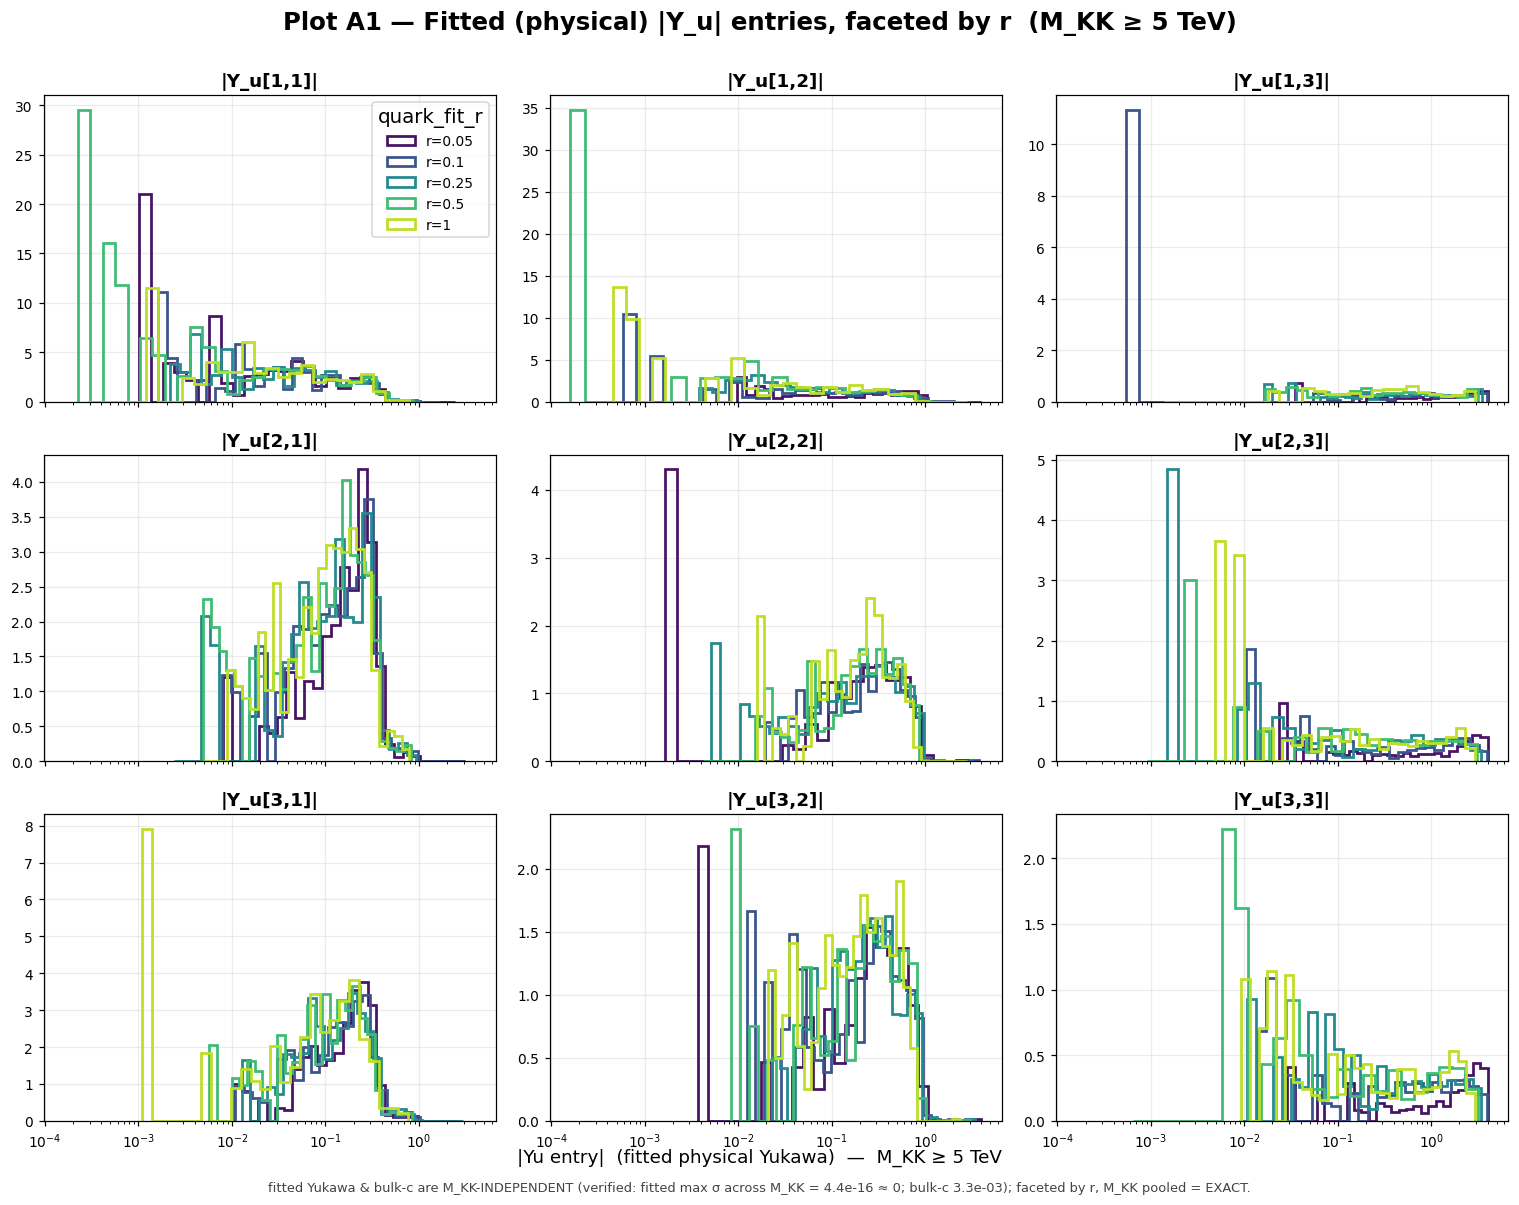

In [7]:
def grid_3x3(sub_df, prefix, title, fname, logx=True):
    fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharex=logx)
    rcolors = plt.cm.viridis(np.linspace(0.05, 0.9, len(R_VALS)))
    for i in range(3):
        for j in range(3):
            ax = axes[i, j]
            col = f"{prefix}_{i}{j}"
            for rv, c in zip(R_VALS, rcolors):
                vals = sub_df.loc[sub_df.r == rv, col].dropna().values
                if len(vals) == 0:
                    continue
                if logx:
                    vals = vals[vals > 0]
                    bins = np.logspace(np.log10(max(vals.min(), 1e-4)),
                                       np.log10(vals.max() + 1e-12), 28)
                else:
                    bins = 28
                ax.hist(vals, bins=bins, histtype="step", linewidth=1.8,
                        color=c, label=f"r={rv:g}", density=True)
            if logx:
                ax.set_xscale("log")
            ax.set_title(f"|{prefix.replace('Yu','Y_u').replace('Yd','Y_d')}[{i+1},{j+1}]|",
                         fontsize=12)
            ax.tick_params(labelsize=9)
    axes[0, 0].legend(fontsize=9, title="quark_fit_r")
    fig.suptitle(title, fontsize=16, fontweight="bold")
    fig.text(0.5, 0.028, f"|{prefix[:2]} entry|  (fitted physical Yukawa)  —  M_KK ≥ 5 TeV",
             ha="center", fontsize=12)
    fig.text(0.5, 0.004, AB_MKK_NOTE, ha="center", fontsize=8.5, color="#444444")
    fig.tight_layout(rect=(0, 0.02, 1, 0.985))
    fig.savefig(os.path.join(FIGDIR, fname), bbox_inches="tight")
    return fig

grid_3x3(sub, "Yu",
         "Plot A1 — Fitted (physical) |Y_u| entries, faceted by r  (M_KK ≥ 5 TeV)",
         "A1_fitted_Yu_grid.png")
plt.show()

### A2 — Fitted (physical) |Y_d| as a 3×3 grid of panels, faceted by r

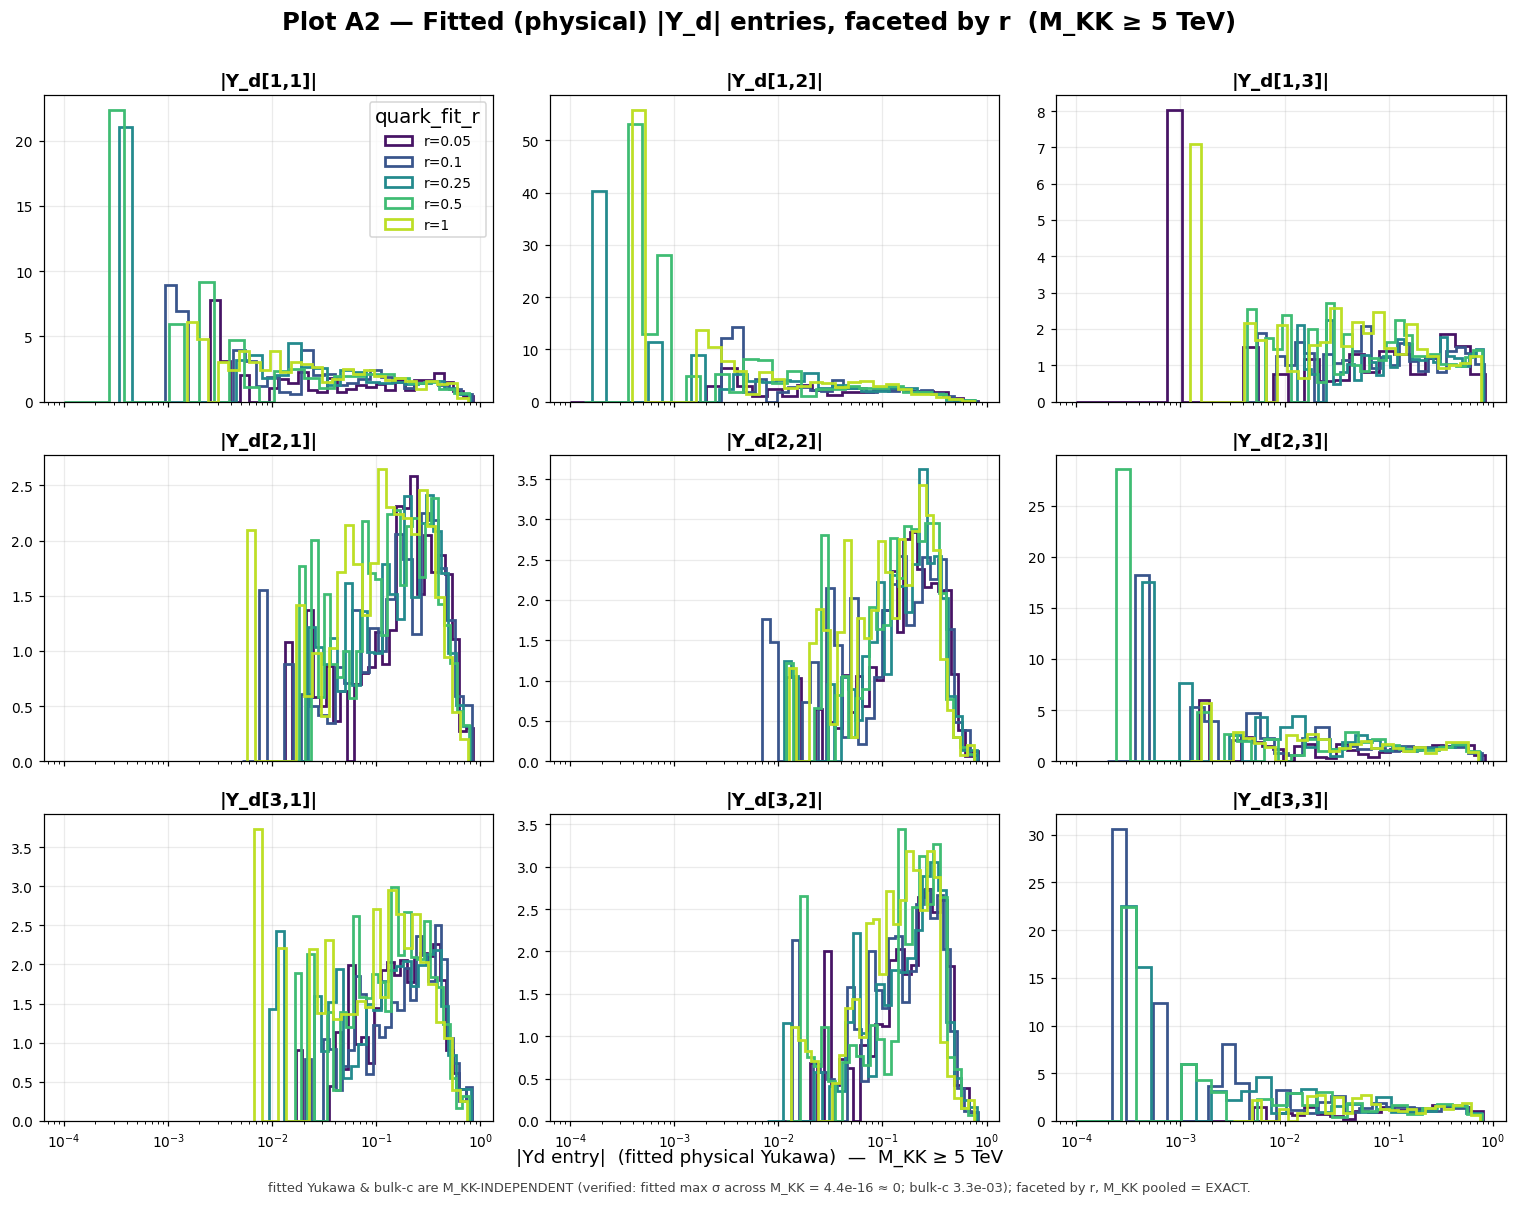

In [8]:
grid_3x3(sub, "Yd",
         "Plot A2 — Fitted (physical) |Y_d| entries, faceted by r  (M_KK ≥ 5 TeV)",
         "A2_fitted_Yd_grid.png")
plt.show()

### A3 — Median fitted |Y_u| / |Y_d| texture heatmaps, per r

A compact "what does the Yukawa look like" view: the median `|Y_ij|` over the
subsample, as a 3×3 heatmap, one column per `r`. This makes the **texture / hierarchy**
obvious at a glance (bright top-right corner = top Yukawa; dim first row/column).

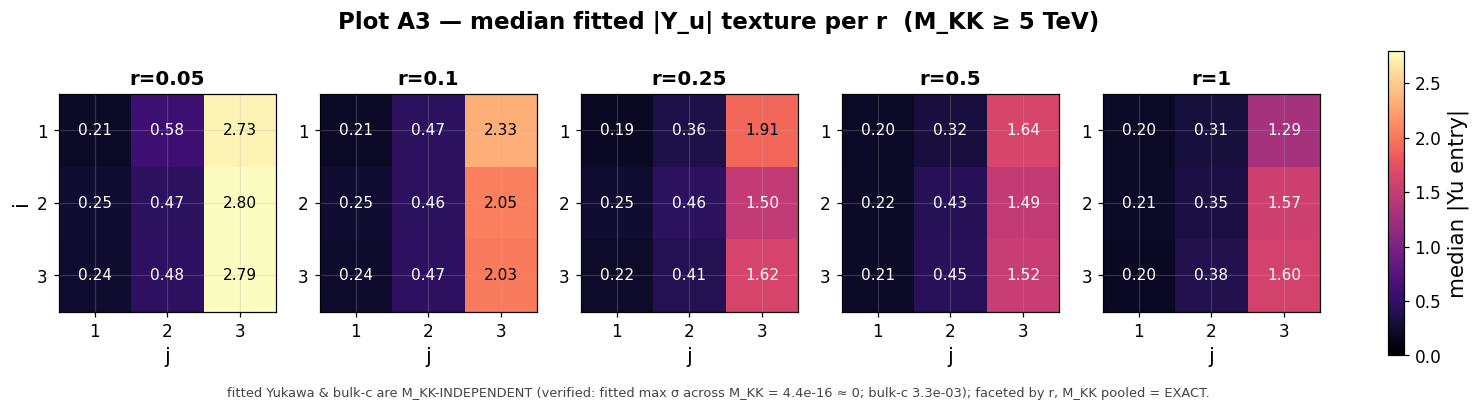

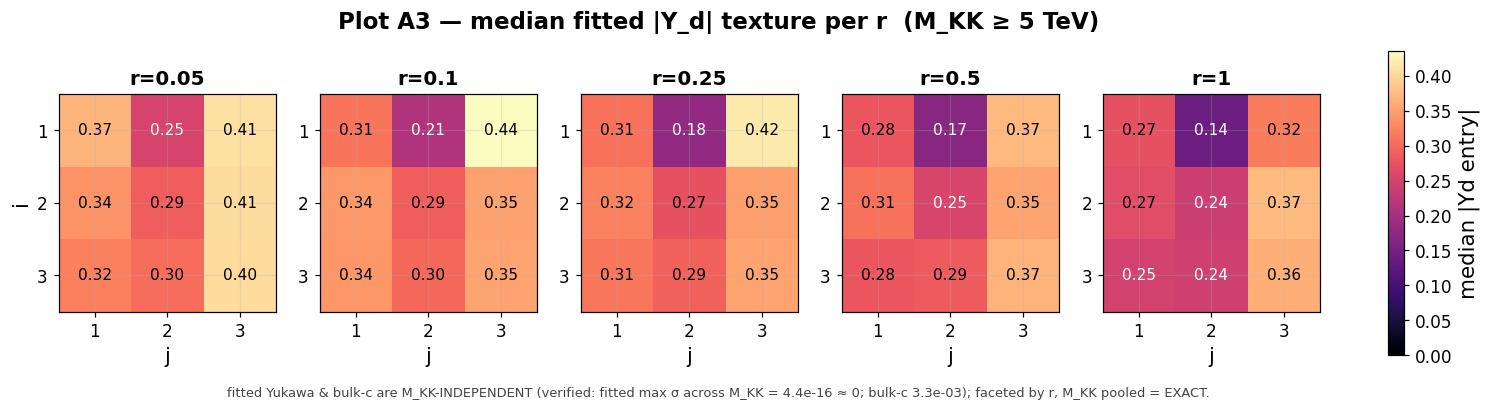

In [9]:
def texture_heatmaps(sub_df, prefix, title, fname):
    fig, axes = plt.subplots(1, len(R_VALS), figsize=(3.2 * len(R_VALS), 3.6))
    mats = []
    for rv in R_VALS:
        m = np.zeros((3, 3))
        sd = sub_df[sub_df.r == rv]
        for i in range(3):
            for j in range(3):
                m[i, j] = np.nanmedian(sd[f"{prefix}_{i}{j}"].values)
        mats.append(m)
    vmax = np.nanmax([np.nanmax(m) for m in mats])
    for ax, rv, m in zip(axes, R_VALS, mats):
        im = ax.imshow(m, cmap="magma", vmin=0, vmax=vmax)
        ax.set_title(f"r={rv:g}", fontsize=13)
        ax.set_xticks(range(3), [1, 2, 3]); ax.set_yticks(range(3), [1, 2, 3])
        ax.set_xlabel("j");
        if rv == R_VALS[0]:
            ax.set_ylabel("i")
        for i in range(3):
            for j in range(3):
                ax.text(j, i, f"{m[i,j]:.2f}", ha="center", va="center",
                        color="white" if m[i, j] < 0.6 * vmax else "black", fontsize=10)
    fig.colorbar(im, ax=axes, fraction=0.025, label=f"median |{prefix[:2]} entry|")
    fig.suptitle(title, fontsize=15, fontweight="bold")
    fig.text(0.5, 0.005, AB_MKK_NOTE, ha="center", fontsize=8.5, color="#444444")
    fig.savefig(os.path.join(FIGDIR, fname), bbox_inches="tight")
    return fig

texture_heatmaps(sub, "Yu",
                 "Plot A3 — median fitted |Y_u| texture per r  (M_KK ≥ 5 TeV)",
                 "A3_fitted_Yu_texture.png")
plt.show()
texture_heatmaps(sub, "Yd",
                 "Plot A3 — median fitted |Y_d| texture per r  (M_KK ≥ 5 TeV)",
                 "A3_fitted_Yd_texture.png")
plt.show()

### A4 — INPUT (anarchic) vs FITTED (physical): max-entry distribution

Contrast the two notions of "the Yukawa". The **input** max-|entry| is the anarchic
prior (`r`/`M_KK`-independent by construction). The **fitted** physical max-|entry|
(`max_abs_quark_yukawa`, available in the full 1M) is pushed up by the geometry fit and
carries the perturbativity cut at 4 — this is the version the constraints actually see.

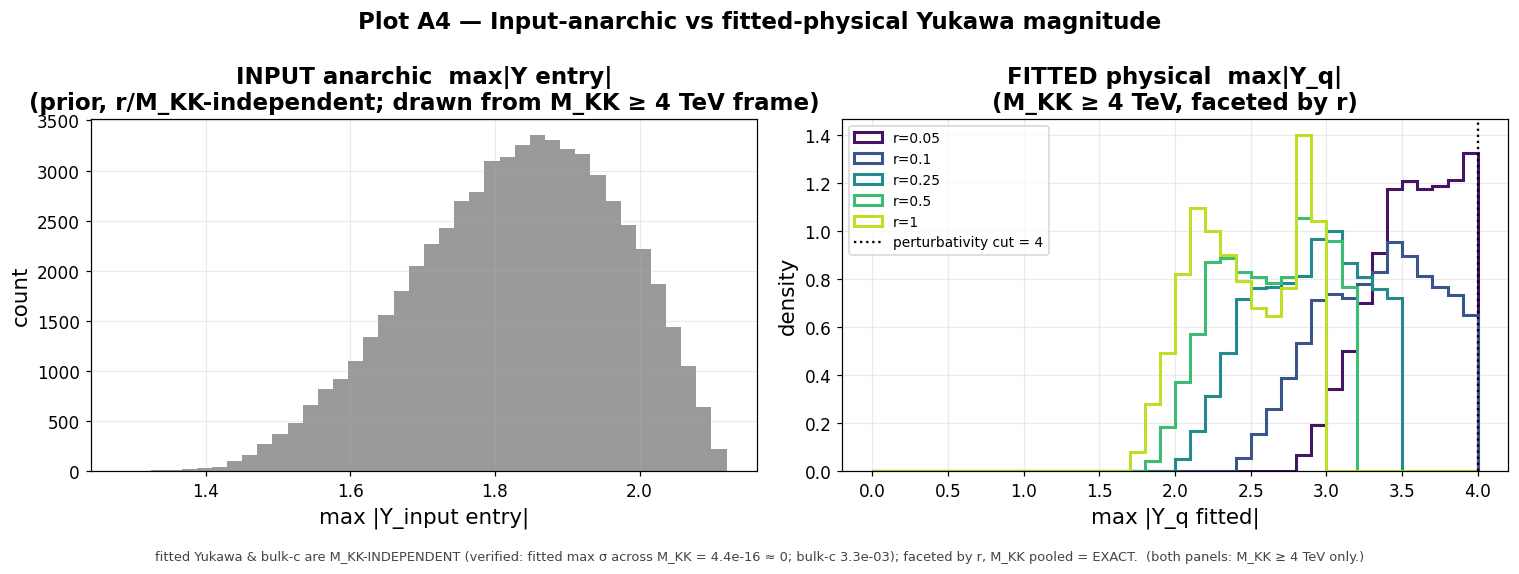

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# input anarchic: max over 18 |entries| per row. Sample from the SAME M_KK >= 4 TeV
# analysis frame `d` (NOT the full cache) so no sub-4-TeV rows leak into this panel.
assert d["M_KK"].isin(MKK_KEEP).all(), "input-panel frame must be M_KK >= 4 TeV only"
samp = d.sample(min(60000, len(d)), random_state=0)
yu_cols = [f"Yu_{i}{j}" for i in range(3) for j in range(3)]
yd_cols = [f"Yd_{i}{j}" for i in range(3) for j in range(3)]
inp_max = samp[yu_cols + yd_cols].abs().max(axis=1)
axes[0].hist(inp_max, bins=40, color="#888888", alpha=0.85)
axes[0].set_title("INPUT anarchic  max|Y entry|\n(prior, r/M_KK-independent; drawn from M_KK ≥ 4 TeV frame)")
axes[0].set_xlabel("max |Y_input entry|"); axes[0].set_ylabel("count")

rcolors = plt.cm.viridis(np.linspace(0.05, 0.9, len(R_VALS)))
for rv, c in zip(R_VALS, rcolors):
    vals = d.loc[d.r == rv, "max_abs_quark_yukawa"].dropna().values
    axes[1].hist(vals, bins=np.linspace(0, 4, 41), histtype="step",
                 linewidth=2, color=c, label=f"r={rv:g}", density=True)
axes[1].axvline(4.0, color="k", ls=":", label="perturbativity cut = 4")
axes[1].set_title("FITTED physical  max|Y_q|\n(M_KK ≥ 4 TeV, faceted by r)")
axes[1].set_xlabel("max |Y_q fitted|"); axes[1].set_ylabel("density")
axes[1].legend(fontsize=9)
fig.suptitle("Plot A4 — Input-anarchic vs fitted-physical Yukawa magnitude",
             fontsize=15, fontweight="bold")
fig.text(0.5, -0.02, AB_MKK_NOTE + "  (both panels: M_KK ≥ 4 TeV only.)",
         ha="center", fontsize=8.5, color="#444444")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "A4_input_vs_fitted_maxY.png"), bbox_inches="tight")
plt.show()

# Plot B — Bulk localization masses (c_Q, c_u, c_d)

The bulk masses `c` set the geometric localization of each generation's zero mode
(`c > 1/2` → UV-localized / light; `c < 1/2` → IR-localized / heavy). These are the
**fitted** values (`bulk_c_Q/u/d`, length-3) and are stored for all 1M rows. Like the
fitted Yukawa, bulk `c` is **M_KK-INDEPENDENT by construction** (the geometry fit takes
`r, Lambda_IR, k`, not `M_KK`; verified above, max σ across M_KK ≈ 1e-3 = finite-sampling
noise). We nonetheless still **facet by `M_KK` and overlay `r`** here — the near-identical
facets are themselves the visual proof of M_KK-independence, and no scale is silently
pooled. The third (heaviest) generation sits near / below 1/2 (IR-localized top/bottom),
the first two are UV-localized.

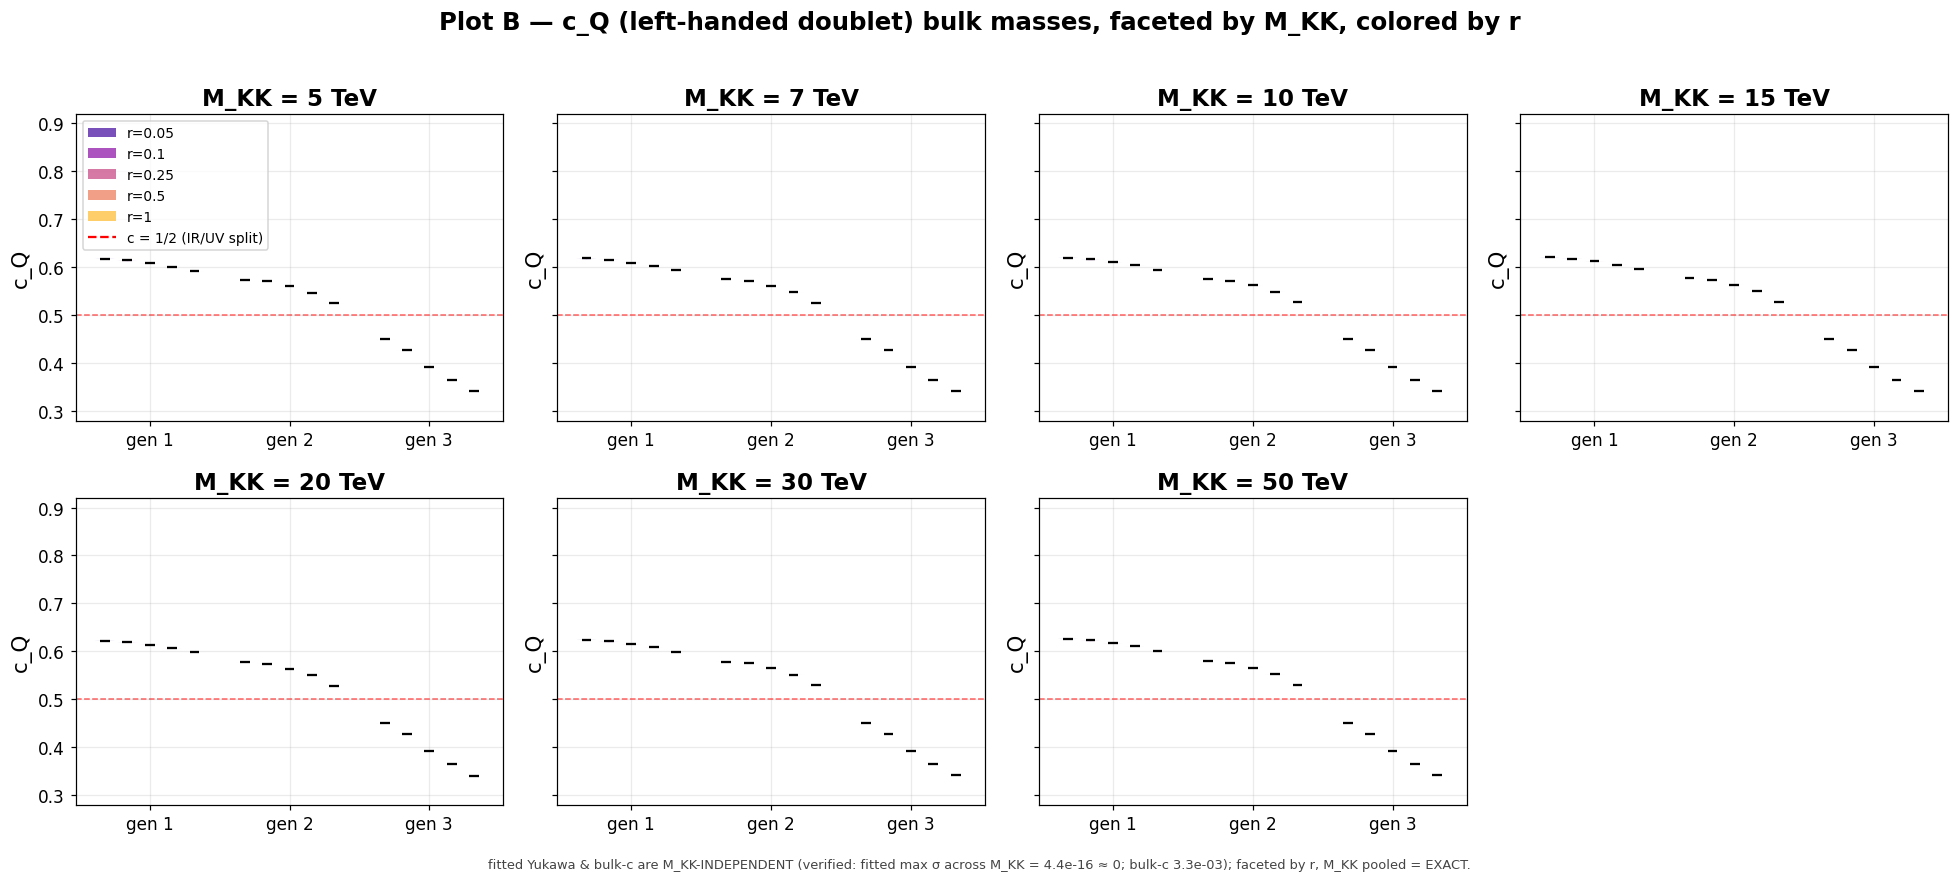

In [11]:
def bulk_violins(prefix, title, fname):
    fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
    axes = axes.ravel()
    rpos = {rv: k for k, rv in enumerate(R_VALS)}
    rcolors = plt.cm.plasma(np.linspace(0.1, 0.85, len(R_VALS)))
    for ax, mkk in zip(axes, MKK_KEEP):
        dm = d[d.M_KK == mkk]
        for gen in range(3):
            for rv in R_VALS:
                vals = dm.loc[dm.r == rv, f"{prefix}{gen+1}"].dropna().values
                if len(vals) == 0:
                    continue
                pos = gen + (rpos[rv] - (len(R_VALS) - 1) / 2) * 0.16
                bp = ax.violinplot([vals], positions=[pos], widths=0.14,
                                   showmedians=True, showextrema=False)
                for b in bp["bodies"]:
                    b.set_facecolor(rcolors[rpos[rv]]); b.set_alpha(0.7)
                bp["cmedians"].set_color("black")
        ax.axhline(0.5, color="red", ls="--", lw=1, alpha=0.6)
        ax.set_xticks(range(3), ["gen 1", "gen 2", "gen 3"])
        ax.set_title(f"M_KK = {mkk/1000:g} TeV")
        ax.set_ylim(0.28, 0.92)
        ax.set_ylabel(prefix.replace("c", "c_").upper().replace("C_", "c_"))
    for ax in axes[len(MKK_KEEP):]:
        ax.set_visible(False)
    handles = [Patch(facecolor=rcolors[k], alpha=0.7, label=f"r={rv:g}")
               for k, rv in enumerate(R_VALS)]
    handles.append(Line2D([0], [0], color="red", ls="--", label="c = 1/2 (IR/UV split)"))
    axes[0].legend(handles=handles, fontsize=9, loc="upper left")
    fig.suptitle(title, fontsize=16, fontweight="bold")
    fig.text(0.5, 0.005, AB_MKK_NOTE, ha="center", fontsize=8.5, color="#444444")
    fig.tight_layout(rect=(0, 0.02, 1, 0.97))
    fig.savefig(os.path.join(FIGDIR, fname), bbox_inches="tight")
    return fig

bulk_violins("cQ", "Plot B — c_Q (left-handed doublet) bulk masses, faceted by M_KK, colored by r",
             "B_bulk_cQ.png")
plt.show()

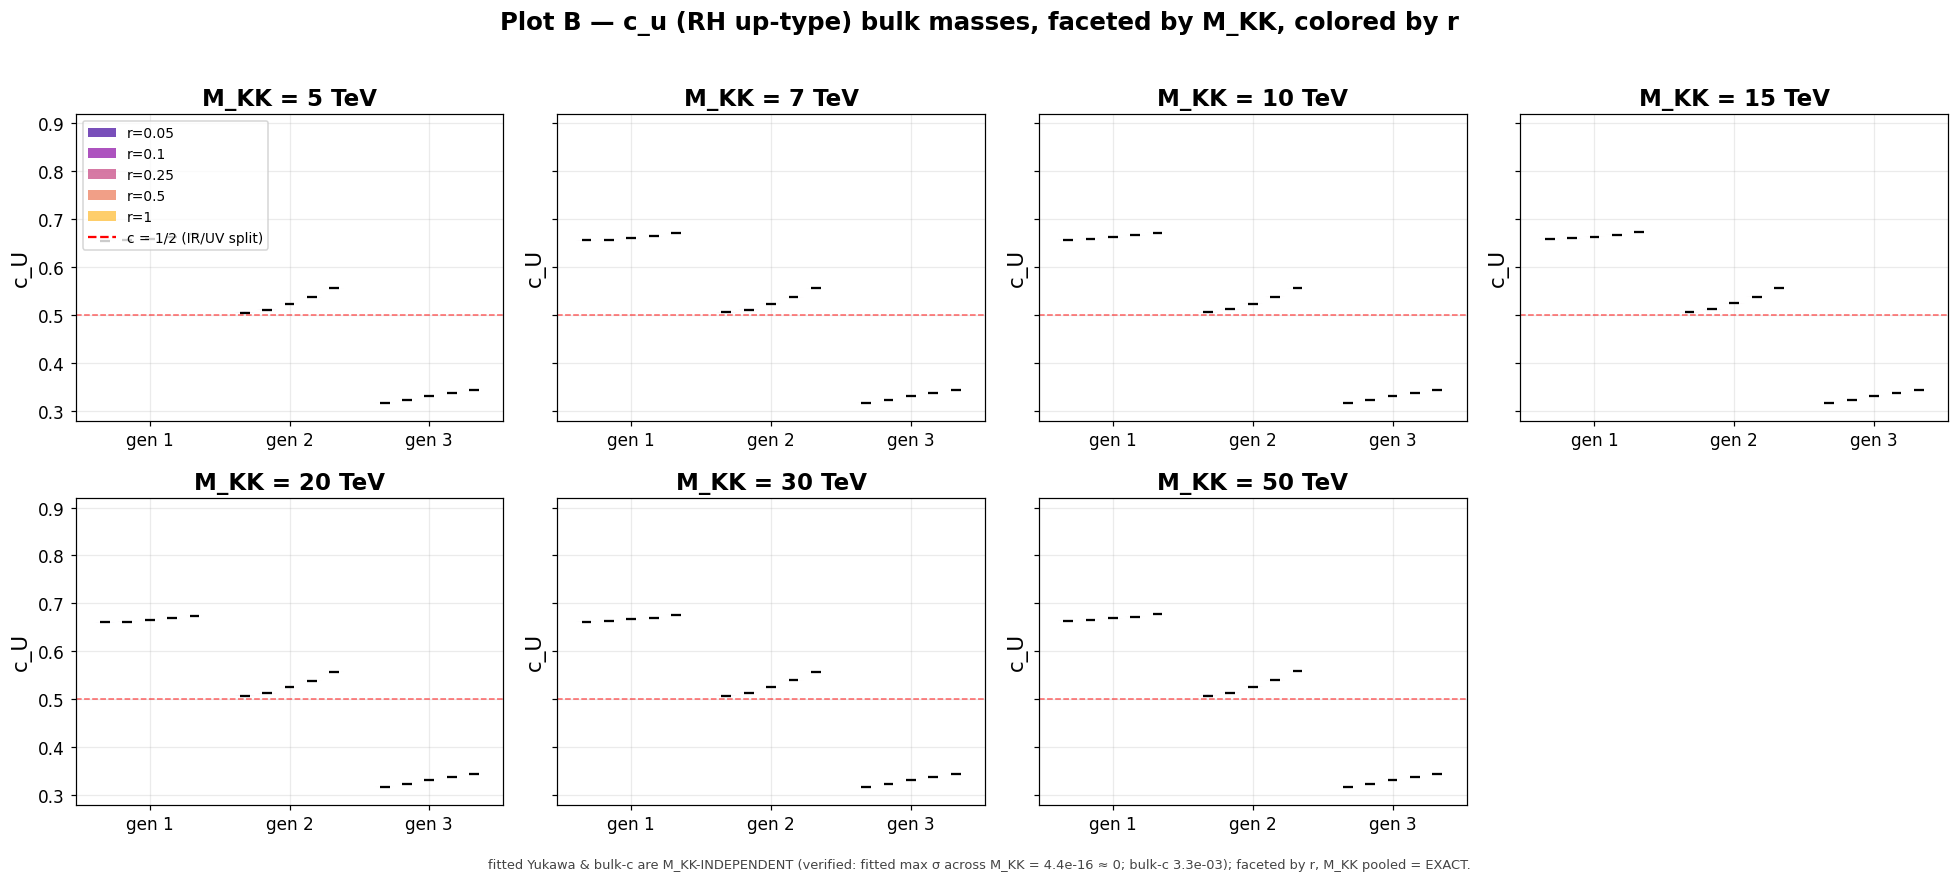

In [12]:
bulk_violins("cu", "Plot B — c_u (RH up-type) bulk masses, faceted by M_KK, colored by r",
             "B_bulk_cu.png")
plt.show()

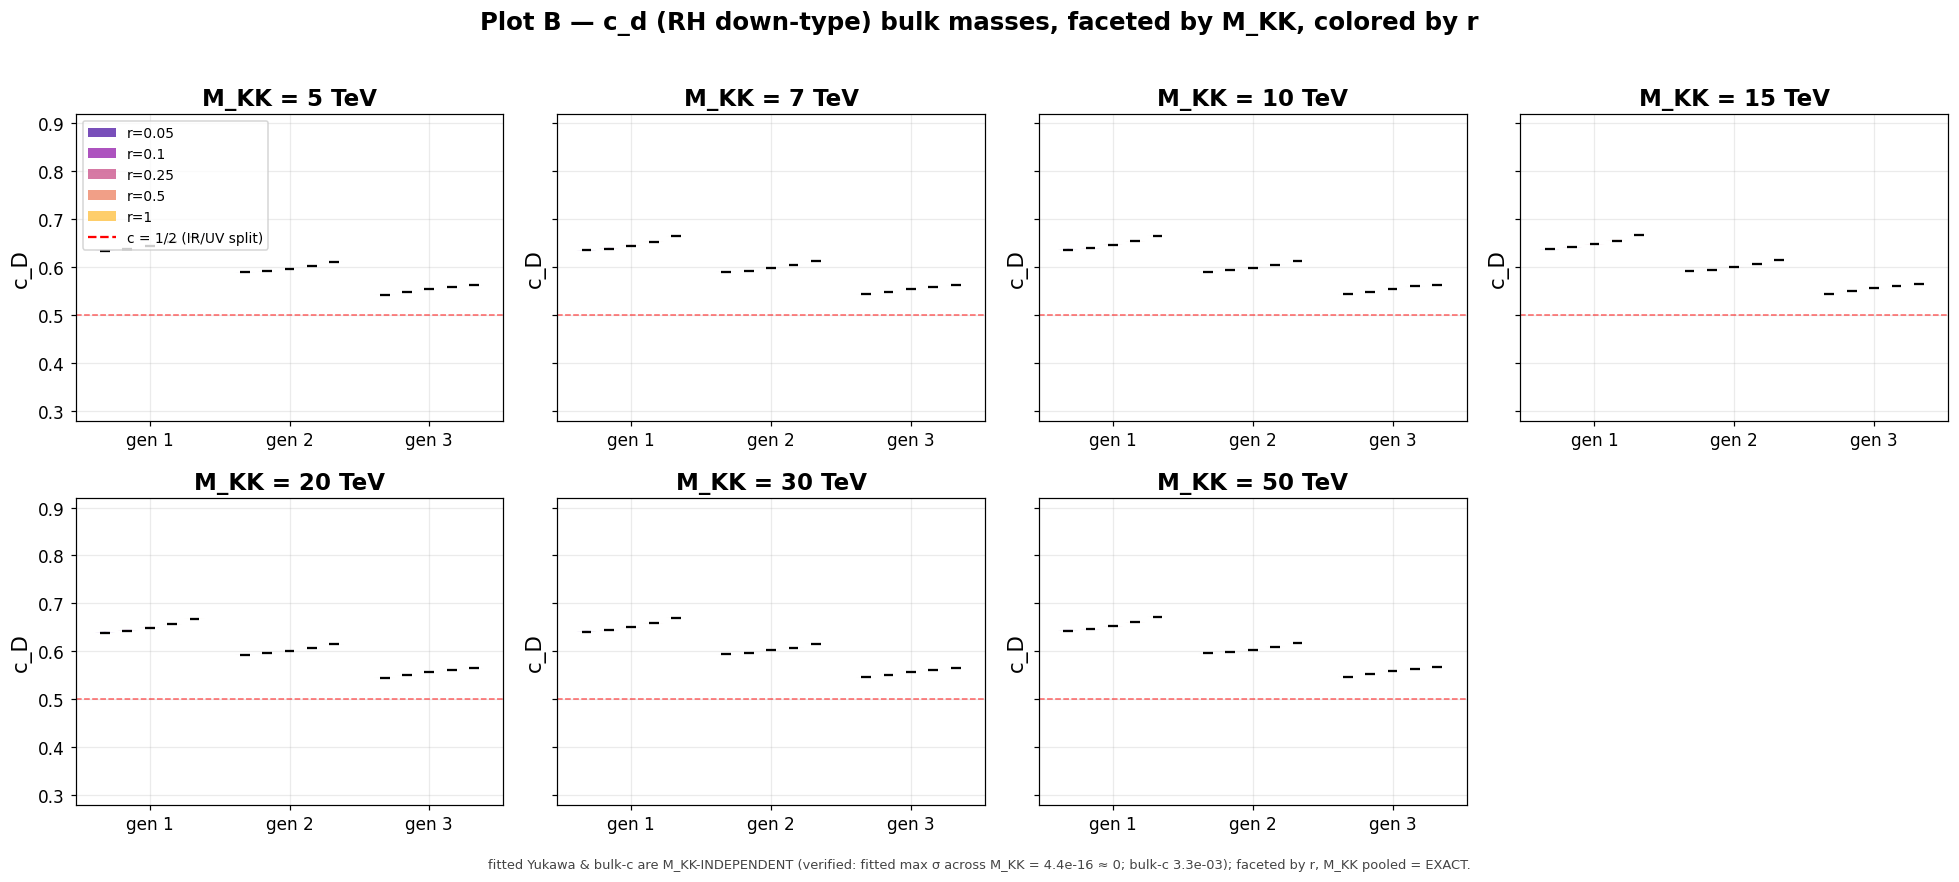

In [13]:
bulk_violins("cd", "Plot B — c_d (RH down-type) bulk masses, faceted by M_KK, colored by r",
             "B_bulk_cd.png")
plt.show()

### B-summary — median c per generation vs r, faceted by M_KK

A compact view of how localization shifts with `r` (the up/down doublet weight). Note
c_Q, c_u, c_d are essentially **M_KK-independent** (the geometry fit doesn't use the KK
gluon mass), so the facets look nearly identical — which is itself the message: the
localization is set by `r` and the mass/CKM targets, not by the KK scale.

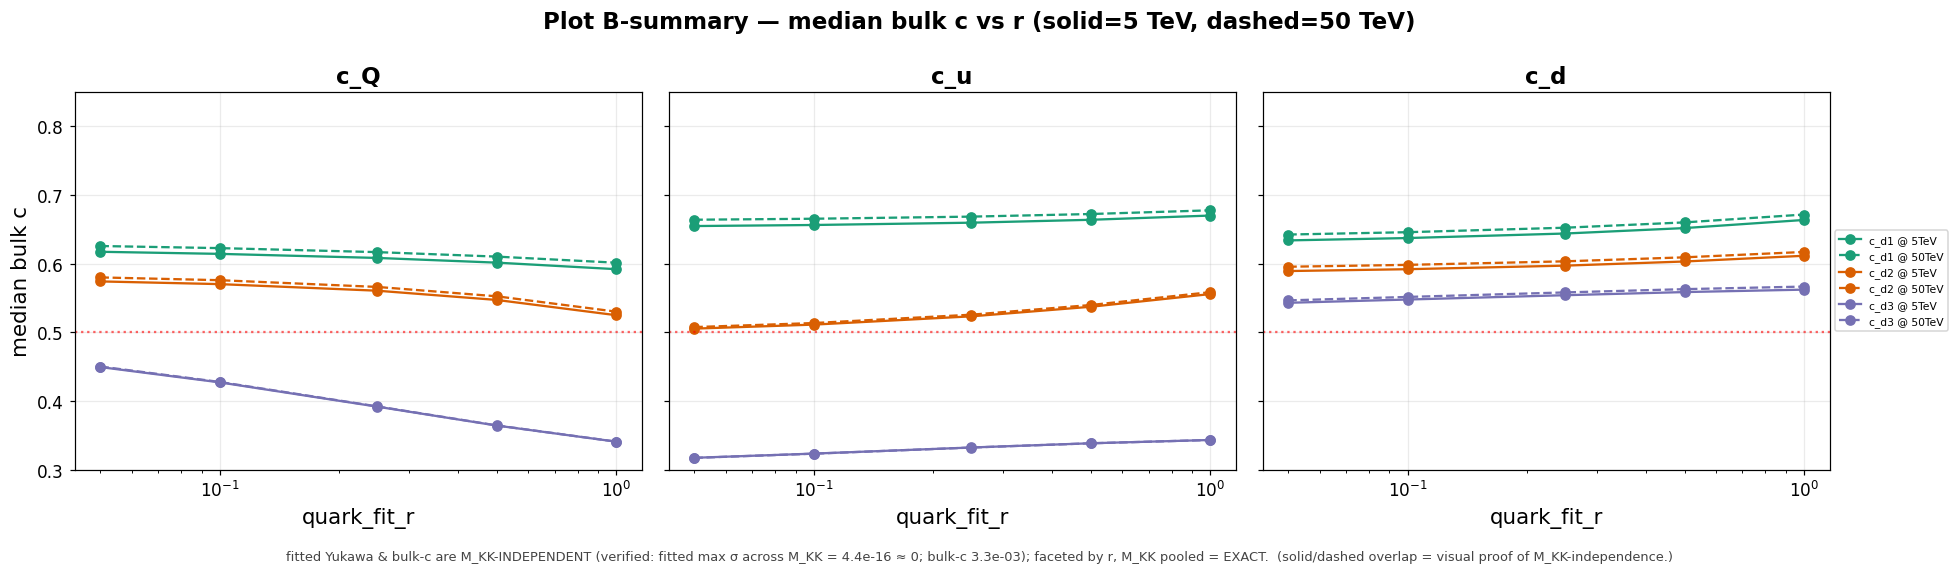

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
specs = [("cQ", "c_Q"), ("cu", "c_u"), ("cd", "c_d")]
gcolors = ["#1b9e77", "#d95f02", "#7570b3"]
for ax, (pref, lab) in zip(axes, specs):
    for gen in range(3):
        for mkk, ls in zip([5000.0, 50000.0], ["-", "--"]):
            dm = d[d.M_KK == mkk]
            med = dm.groupby("r")[f"{pref}{gen+1}"].median()
            ax.plot(med.index, med.values, marker="o", color=gcolors[gen], ls=ls,
                    label=f"{lab}{gen+1} @ {mkk/1000:g}TeV" if gen == 0 or True else None)
    ax.axhline(0.5, color="red", ls=":", alpha=0.6)
    ax.set_xscale("log"); ax.set_xlabel("quark_fit_r")
    ax.set_title(lab); ax.set_ylim(0.3, 0.85)
axes[0].set_ylabel("median bulk c")
axes[2].legend(fontsize=7, ncols=1, loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.suptitle("Plot B-summary — median bulk c vs r (solid=5 TeV, dashed=50 TeV)",
             fontsize=15, fontweight="bold")
fig.text(0.5, -0.02, AB_MKK_NOTE + "  (solid/dashed overlap = visual proof of "
         "M_KK-independence.)", ha="center", fontsize=8.5, color="#444444")
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "B_bulk_c_summary.png"), bbox_inches="tight")
plt.show()

# Plot C — The constraint-carving plot

**Goal.** `M_KK` on the y-axis, a structural axis `X` on the x-axis, and one
line/curve per constraint showing **how hard it pushes** to raise `M_KK`.

**Choosing X (documented experiments).** We tried:
1. **`X = quark_fit_r`** — the swept structural parameter (the up/down doublet weight in
   `C_Q = r·Y_uY_u† + Y_dY_d†`). This is the natural primary axis: it directly tunes the
   flavor-violating spurion that ΔF=2 constraints see. **Chosen as primary.**
2. **`X = RH-down compositeness` proxy** `= f(c_d)` — specifically `min over gen of
   (1/2 - c_d)` mapped to IR overlap; larger = more composite RH down quarks = stronger
   dipole/ΔF=2. Tried as an alternative (panel set 2). It correlates with constraint
   strength but is *derived from the same fit*, so it mostly re-expresses `r`; `r` reads
   more cleanly as the swept knob.
3. **`X = Yukawa anarchy`** `= max_abs_quark_yukawa` (perturbativity proxy). Tried; it
   spreads constraint strength but is noisy and not monotonic — less informative than `r`.

**The honest >4 TeV story.** Above the 4 TeV floor, **binary exclusion is essentially
empty**: rigorous ΔF=2 reach is ~1–3 TeV (already satisfied), and the only constraint
that actually vetoes a point past 4 TeV is the proxy `EW001` (oblique S,T,U) at 5 TeV —
nothing vetoes at ≥7 TeV. So a veto-fraction carving plot is a flat zero above 4 TeV.
Instead we rank by **median `ratio`** (proximity to bound; veto threshold `ratio = 1`)
per `(X, M_KK)` cell — this reveals *how close each constraint sits to biting* even
when it does not exclude.

**Crucial honesty caveat — `ratio` is not the same as a veto.** A constraint only
removes a point if it is (i) **HARD** severity **and** (ii) tagged **rigorous or
proxy** — this is exactly the harness `survives_all_HARD_inclusive` rule. Several
**partial** (NEEDS-HUMAN-PHYSICS) entries carry `ratio ≥ 1` or even ≫ 1 (notably
`T010` Z→bb pull, `B034`, `EW003`, and the placeholder-`ratio=1` nonleptonic/EDM
proxies `C003/K003/K013/B032`). These **do NOT carve anything**, but for two distinct
reasons that we name honestly per id: `T010` (and `T001/T002/T011`) are **`partial` &
HARD** — non-vetoing because their matching is *incomplete* (`partial`), NOT because
they are soft; the rest (`B032–B034`, `C003`, `K003`, `K013`, `EW003`, `E004–E009`)
are **`partial` & INFO/SOFT**. In all cases the high ratio reflects an *unfinished*
SM/RS prediction, not a real exclusion. We therefore split the dominant panel into
**veto-eligible carvers** (can
actually raise `M_KK`) vs **advisory-only high-ratio partials** (flagged, never veto),
so the reader is not misled. We organize C1 as: **veto-eligible dominant**,
**veto-eligible subdominant**, and **advisory-only / inactive**.

In [15]:
# Build a "carving" table: for each (r, M_KK) cell, median ratio per constraint (over
# evaluated rows). ratio ~ how close to the bound; >1 would veto (only if veto-eligible).
RATIO_COLS = {cid: f"{cid}__ratio" for cid in ALLOWLIST}
EVAL_COLS = {cid: f"{cid}__eval" for cid in ALLOWLIST}

# Veto eligibility = the harness rule behind survives_all_HARD_inclusive:
#   HARD severity AND tag in {rigorous, proxy}. Everything else (INFO/SOFT, or any
#   `partial`) is advisory-only and can NEVER remove a point.
def modal_sev(cid):
    s = df[f"{cid}__sev"]; s = s[s.astype(str) != ""]
    return s.mode().iloc[0] if len(s) else ""
SEV = {cid: modal_sev(cid) for cid in ALLOWLIST}
VETO_ELIGIBLE = {cid for cid in ALLOWLIST
                 if SEV[cid] == "HARD" and TAG[cid] in ("rigorous", "proxy")}
print("veto-eligible (HARD & rigorous/proxy):", sorted(VETO_ELIGIBLE))
advisory = sorted(set(ALLOWLIST) - VETO_ELIGIBLE)
print("advisory-only (never veto):", advisory)

def carving_table(frame, xcol):
    """median ratio + true (eligible) veto fraction per (xcol, M_KK) per constraint."""
    rows = []
    xvals = sorted(frame[xcol].unique())
    for xv in xvals:
        for mkk in MKK_KEEP:
            cell = frame[(frame[xcol] == xv) & (frame.M_KK == mkk)]
            if len(cell) == 0:
                continue
            for cid in ALLOWLIST:
                ev = cell[cell[EVAL_COLS[cid]]]
                if len(ev) == 0:
                    continue
                ratios = ev[RATIO_COLS[cid]].dropna()
                if len(ratios) == 0:
                    continue
                # only count as a veto if the constraint is actually veto-eligible
                veto = (~ev[f"{cid}__pass"]).mean() if cid in VETO_ELIGIBLE else 0.0
                rows.append({
                    "x": xv, "M_KK": mkk, "cid": cid, "tag": TAG[cid],
                    "eligible": cid in VETO_ELIGIBLE,
                    "median_ratio": float(ratios.median()),
                    "p90_ratio": float(ratios.quantile(0.90)),
                    "veto_frac": float(veto),
                })
    return pd.DataFrame(rows)

carve_r = carving_table(d, "r")
print("\ncarving table (X=r) rows:", len(carve_r))

# Rank constraints by their peak median_ratio over all cells (how close to biting).
peak = (carve_r.groupby(["cid", "tag", "eligible"])["median_ratio"].max()
        .reset_index().sort_values("median_ratio", ascending=False))
print("\nTop constraints by peak median ratio (X=r, M_KK>=5TeV)  "
      "[eligible=True can actually veto]:")
print(peak.head(18).to_string(index=False))

veto-eligible (HARD & rigorous/proxy): ['B001', 'B002', 'B003', 'B004', 'B011', 'B012', 'B013', 'B014', 'C001', 'C002', 'EW001', 'K001', 'K002', 'T003', 'T004', 'T005', 'T006', 'T007', 'T008', 'T012', 'T014']
advisory-only (never veto): ['B032', 'B033', 'B034', 'C003', 'E004', 'E006', 'E007', 'E008', 'E009', 'EW003', 'K003', 'K013', 'T001', 'T002', 'T010', 'T011']



carving table (X=r) rows: 1225

Top constraints by peak median ratio (X=r, M_KK>=5TeV)  [eligible=True can actually veto]:
  cid      tag  eligible  median_ratio
 T010  partial     False     52.607370
EW001    proxy      True      1.678050
 B034  partial     False      1.072464
EW003  partial     False      1.024295
 C003  partial     False      1.000000
 K013  partial     False      1.000000
 K003  partial     False      1.000000
 B032  partial     False      1.000000
 B012    proxy      True      0.369326
 E006  partial     False      0.297297
 T011  partial     False      0.262692
 B033  partial     False      0.248956
 K001 rigorous      True      0.219352
 B004 rigorous      True      0.190479
 B003 rigorous      True      0.110312
 E007  partial     False      0.100000
 B002 rigorous      True      0.093713
 T012 rigorous      True      0.092564


### C1 — Carving curves with X = r (the swept structural parameter)

For each constraint we draw, **per `M_KK`**, the median `ratio` vs `r`. The split into
three panels is now by **veto eligibility first, then strength**, so the reader is not
misled by advisory partials with high ratios:
- **C1a — veto-eligible dominant** (HARD & rigorous/proxy, peak median ratio ≥ 0.05):
  constraints that genuinely push on `M_KK`.
- **C1b — veto-eligible subdominant / inactive** (HARD & rigorous/proxy, peak < 0.05).
- **C1c — advisory-only (NON-VETOING) partials**: every entry here is tag=`partial`.
  They are non-vetoing for one of two distinct reasons, named per id in the panel:
  (i) **`partial` & HARD severity** — e.g. **`T010` (Z→bb)**, `T001`, `T002`, `T011`:
  these *are* HARD, but the harness rule requires tag ∈ {rigorous, proxy} to veto, and
  their matching is incomplete (`partial`, NEEDS-HUMAN-PHYSICS), so they do **not** carve;
  (ii) **`partial` & INFO/SOFT severity** — e.g. `B032–B034`, `C003`, `K003`, `K013`,
  `EW003`, `E004–E009`. High ratios here are unfinished-physics placeholders, not bounds.

Color = tag. Bold curve = 5 TeV (lowest surviving scale); faint = higher `M_KK`.

C1a veto-eligible dominant : ['EW001', 'B012', 'K001', 'B004', 'B003', 'B002', 'T012', 'B011', 'B013']
C1b veto-eligible weak     : ['K002', 'B001', 'B014', 'C001', 'C002', 'T014', 'T003', 'T005', 'T007', 'T006', 'T004', 'T008']
C1c advisory-only (no veto): ['T010', 'B034', 'EW003', 'C003', 'K013', 'K003', 'B032', 'E006', 'T011', 'B033', 'E007', 'T001', 'T002', 'E004']


C1c advisory breakdown by real (tag, severity):
  partial & HARD  (non-vetoing because PARTIAL = incomplete matching): ['T010(HARD)', 'T011(HARD)', 'T001(HARD)', 'T002(HARD)']
  partial & INFO/SOFT (non-vetoing because partial AND soft severity): ['B034(INFO)', 'EW003(SOFT)', 'C003(INFO)', 'K013(INFO)', 'K003(INFO)', 'B032(INFO)', 'E006(INFO)', 'B033(INFO)', 'E007(INFO)', 'E004(INFO)']


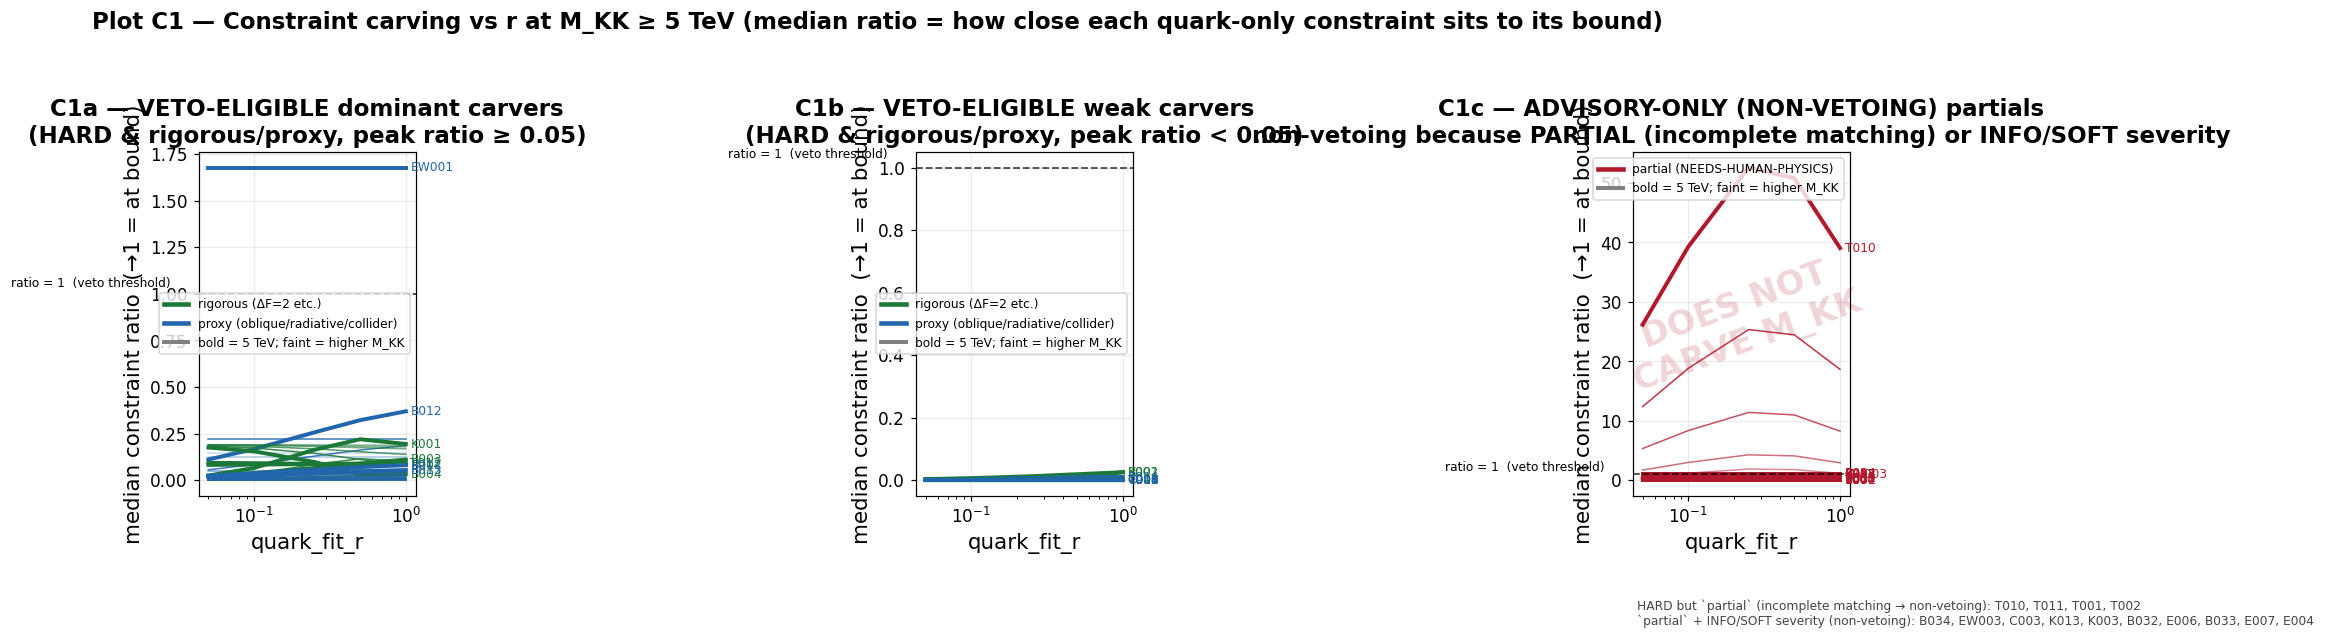

In [16]:
def split_constraints(peak_df):
    elig = peak_df[peak_df.eligible]
    adv = peak_df[~peak_df.eligible]
    dom = elig.loc[elig.median_ratio >= 0.05, "cid"].tolist()
    sub_ = elig.loc[elig.median_ratio < 0.05, "cid"].tolist()
    advisory_ids = adv["cid"].tolist()
    return dom, sub_, advisory_ids

dom_ids, sub_ids, adv_ids = split_constraints(peak)
print("C1a veto-eligible dominant :", dom_ids)
print("C1b veto-eligible weak     :", sub_ids)
print("C1c advisory-only (no veto):", adv_ids)

def carving_panel(ax, carve, ids, title, xcol_label, xlog=True):
    mkk_alpha = {m: a for m, a in zip(MKK_KEEP, np.linspace(1.0, 0.25, len(MKK_KEEP)))}
    seen_tags = set()
    for cid in ids:
        sub_c = carve[carve.cid == cid]
        for mkk in MKK_KEEP:
            cc = sub_c[sub_c.M_KK == mkk].sort_values("x")
            if len(cc) < 2:
                continue
            lw = 2.6 if mkk == 5000.0 else 1.0
            ax.plot(cc["x"], cc["median_ratio"], color=TAG_COLOR[TAG[cid]],
                    alpha=mkk_alpha[mkk], lw=lw)
        # annotate at the 5TeV, largest-x end
        end = sub_c[sub_c.M_KK == 5000.0].sort_values("x")
        if len(end):
            ax.annotate(cid, (end["x"].iloc[-1], end["median_ratio"].iloc[-1]),
                        fontsize=8, color=TAG_COLOR[TAG[cid]],
                        xytext=(3, 0), textcoords="offset points", va="center")
        seen_tags.add(TAG[cid])
    ax.axhline(1.0, color="k", ls="--", lw=1.2, alpha=0.7)
    ax.text(ax.get_xlim()[0], 1.02, "ratio = 1  (veto threshold)", fontsize=8, va="bottom")
    if xlog:
        ax.set_xscale("log")
    ax.set_xlabel(xcol_label)
    ax.set_ylabel("median constraint ratio  (→1 = at bound)")
    ax.set_title(title)
    handles = [Line2D([0], [0], color=TAG_COLOR[t], lw=3, label=TAG_LABEL[t])
               for t in ("rigorous", "proxy", "partial") if t in seen_tags]
    handles.append(Line2D([0], [0], color="gray", lw=2.6, label="bold = 5 TeV; faint = higher M_KK"))
    ax.legend(handles=handles, fontsize=8, loc="best")

fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))
carving_panel(axes[0], carve_r, dom_ids,
              "C1a — VETO-ELIGIBLE dominant carvers\n(HARD & rigorous/proxy, peak ratio ≥ 0.05)",
              "quark_fit_r")
carving_panel(axes[1], carve_r, sub_ids,
              "C1b — VETO-ELIGIBLE weak carvers\n(HARD & rigorous/proxy, peak ratio < 0.05)",
              "quark_fit_r")
# Accurate non-veto reason per advisory id. The harness rule is: a point is removed
# only by HARD AND tag in {rigorous, proxy}. So an entry is NON-VETOING if EITHER its
# tag is `partial` (incomplete matching: no first-principles SM/RS prediction yet —
# this holds even when its severity is HARD, e.g. T010 Z→bb) OR its severity is
# INFO/SOFT. We name each correctly per its real (tag, severity).
adv_partial_hard = [c for c in adv_ids if TAG[c] == "partial" and SEV[c] == "HARD"]
adv_partial_soft = [c for c in adv_ids if TAG[c] == "partial" and SEV[c] in ("SOFT", "INFO")]
adv_other = [c for c in adv_ids
             if c not in adv_partial_hard and c not in adv_partial_soft]
print("C1c advisory breakdown by real (tag, severity):")
print("  partial & HARD  (non-vetoing because PARTIAL = incomplete matching):",
      [f"{c}({SEV[c]})" for c in adv_partial_hard])
print("  partial & INFO/SOFT (non-vetoing because partial AND soft severity):",
      [f"{c}({SEV[c]})" for c in adv_partial_soft])
if adv_other:
    print("  other:", [(c, TAG[c], SEV[c]) for c in adv_other])

carving_panel(axes[2], carve_r, adv_ids,
              "C1c — ADVISORY-ONLY (NON-VETOING) partials\n"
              "non-vetoing because PARTIAL (incomplete matching) or INFO/SOFT severity",
              "quark_fit_r")
# Honest, per-id reason note (no blanket INFO/SOFT mislabel). T010 (Z→bb) etc. are
# HARD but `partial`, so they still do not veto — that is the point.
_reason_lines = []
if adv_partial_hard:
    _reason_lines.append("HARD but `partial` (incomplete matching → non-vetoing): "
                         + ", ".join(adv_partial_hard))
if adv_partial_soft:
    _reason_lines.append("`partial` + INFO/SOFT severity (non-vetoing): "
                         + ", ".join(adv_partial_soft))
axes[2].text(0.02, -0.30, "\n".join(_reason_lines), transform=axes[2].transAxes,
             ha="left", va="top", fontsize=8, color="#444444")
# banner the advisory panel so nobody mistakes high ratio for a real bound
axes[2].text(0.5, 0.5, "DOES NOT\nCARVE M_KK", transform=axes[2].transAxes,
             ha="center", va="center", fontsize=22, color="#b2182b", alpha=0.18,
             rotation=20, fontweight="bold")
fig.suptitle("Plot C1 — Constraint carving vs r at M_KK ≥ 5 TeV "
             "(median ratio = how close each quark-only constraint sits to its bound)",
             fontsize=15, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(os.path.join(FIGDIR, "C1_carving_vs_r.png"), bbox_inches="tight")
plt.show()

### C2 — The "M_KK on y-axis" carving boundary

The most literal reading of the brief: **M_KK on the y-axis**, `r` on the x-axis, and
one **boundary curve per constraint** = the `M_KK` at which that constraint's median
ratio crosses a chosen pressure level (we use ratio = 0.5, "half-way to the bound", and
also mark the true veto level ratio = 1 where it exists). Constraints whose ratio never
reaches the level within `M_KK ≥ 4 TeV` are listed as non-carving. This directly shows
*which constraint controls the lower edge of allowed M_KK* as a function of `r`.

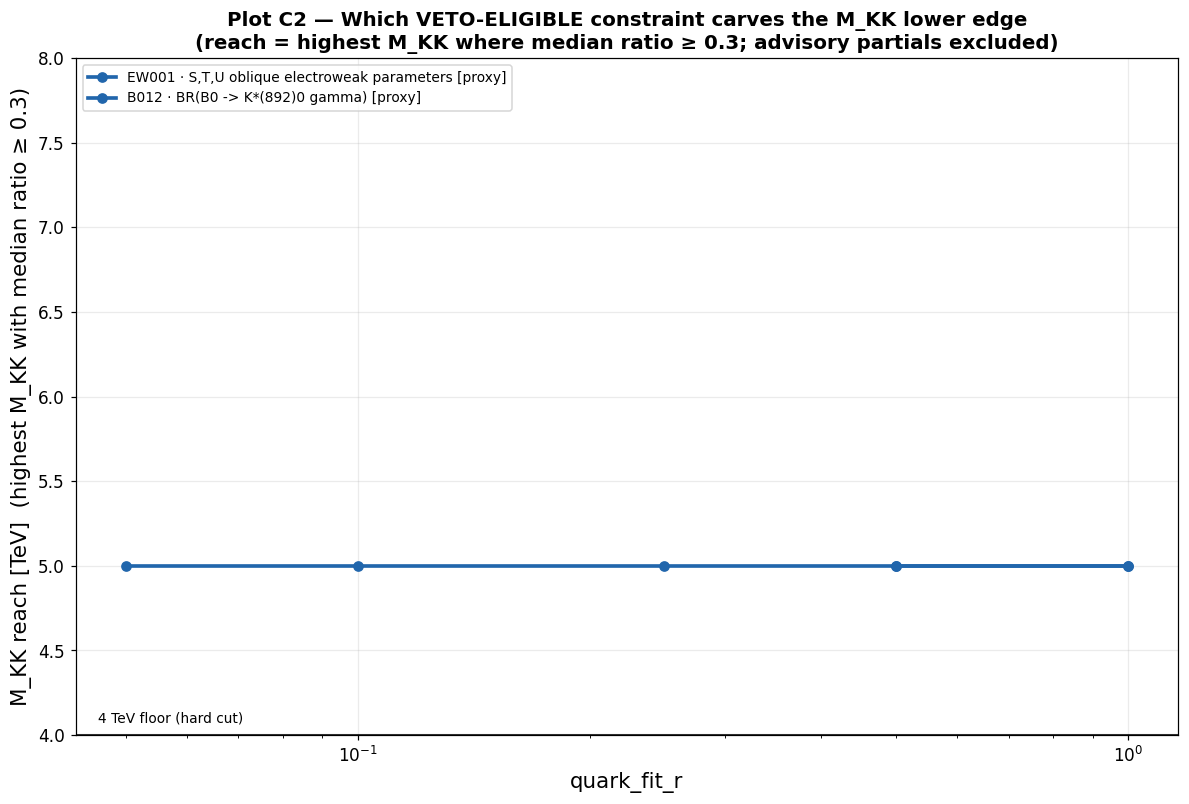


Veto-eligible constraints below the carving level (median ratio < 0.3) at M_KK ≥ 5 TeV — i.e. not carving above the floor:
 cid      tag  median_ratio
K001 rigorous  2.193516e-01
B004 rigorous  1.904787e-01
B003 rigorous  1.103120e-01
B002 rigorous  9.371257e-02
T012 rigorous  9.256365e-02
B011    proxy  8.044763e-02
B013    proxy  5.417373e-02
K002 rigorous  2.575157e-02
B001 rigorous  2.517780e-02
B014    proxy  1.072448e-02
C001 rigorous  3.258368e-03
C002    proxy  3.964576e-05
T014 rigorous  3.366282e-06
T003    proxy  6.634660e-08
T005    proxy  4.984914e-08
T007    proxy  1.687924e-09
T006    proxy  1.446503e-09
T004    proxy  1.848701e-10
T008    proxy  4.737706e-12


In [17]:
def reach_curve(carve, cid, level):
    """For each x, the largest M_KK at which median_ratio >= level (the 'reach')."""
    sub_c = carve[carve.cid == cid]
    xs, ys = [], []
    for xv in sorted(sub_c["x"].unique()):
        cc = sub_c[sub_c.x == xv].sort_values("M_KK")
        above = cc[cc.median_ratio >= level]
        if len(above):
            xs.append(xv); ys.append(above["M_KK"].max() / 1000.0)
    return xs, ys

# Only VETO-ELIGIBLE constraints can actually carve M_KK, so the boundary plot is
# restricted to them (advisory partials are reported separately, not drawn as boundaries).
fig, ax = plt.subplots(figsize=(11, 7.5))
LEVEL = 0.3   # "carving" pressure level on the median ratio (no eligible cstr reaches 0.5)
peak_elig = peak[peak.eligible]
carving_ids = peak_elig.loc[peak_elig.median_ratio >= LEVEL, "cid"].tolist()
noncarving = peak_elig.loc[peak_elig.median_ratio < LEVEL, ["cid", "tag", "median_ratio"]]
for cid in carving_ids:
    xs, ys = reach_curve(carve_r, cid, LEVEL)
    if not xs:
        continue
    ax.plot(xs, ys, marker="o", lw=2.4, color=TAG_COLOR[TAG[cid]],
            label=f"{cid} · {OBSERVABLE[cid]} [{TAG[cid]}]")
ax.axhline(4.0, color="k", ls="-", lw=2, alpha=0.8)
ax.text(0.02, 4.06, "4 TeV floor (hard cut)", fontsize=9, va="bottom",
        transform=ax.get_yaxis_transform())
ax.set_xscale("log")
ax.set_xlabel("quark_fit_r")
ax.set_ylabel(f"M_KK reach [TeV]  (highest M_KK with median ratio ≥ {LEVEL})")
ax.set_ylim(4.0, max(8.0, ax.get_ylim()[1]))  # floor at the 4 TeV hard cut
ax.set_title("Plot C2 — Which VETO-ELIGIBLE constraint carves the M_KK lower edge\n"
             f"(reach = highest M_KK where median ratio ≥ {LEVEL}; advisory partials excluded)",
             fontsize=13, fontweight="bold")
if carving_ids:
    ax.legend(fontsize=9, loc="upper left", ncols=1)
else:
    ax.text(0.5, 0.5, "NO veto-eligible constraint reaches the carving level\n"
            f"(median ratio ≥ {LEVEL}) anywhere at M_KK ≥ 5 TeV",
            transform=ax.transAxes, ha="center", va="center", fontsize=12,
            bbox=dict(boxstyle="round", fc="#ffeeee"))
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "C2_mkk_carving_boundary.png"), bbox_inches="tight")
plt.show()

print(f"\nVeto-eligible constraints below the carving level (median ratio < {LEVEL}) "
      "at M_KK ≥ 5 TeV — i.e. not carving above the floor:")
print(noncarving.sort_values("median_ratio", ascending=False).to_string(index=False))

### C3 — Alternative X: RH-down compositeness, and the veto-fraction honesty panel

**(left) C3a — the ALTERNATIVE structural axis.** Same carving idea but with
`X = RH-down compositeness` proxy `= max_gen (1/2 − c_d)` (larger → more IR-composite RH
down quarks → stronger down-sector dipole/ΔF=2). **This axis is explicitly the
alternative-axis exploration: compositeness is a fit-derived function of `c_d`, which is
set by the same geometry fit that `r` drives, so the x-axis is a monotone re-expression
of the swept `r` and spans `r` by construction** — it is NOT a single-scale result and is
labeled as such on the panel. (`r` reads more cleanly as the swept knob; this is shown as
a cross-check.)

**(right) C3b — the honest binary-veto view, PER r (NOT pooled).** Binary exclusion is
both `M_KK`- and `r`-dependent, so we draw one line **per `r`** (encoded by line style +
marker) for each veto-eligible constraint, never pooling `r`. The panel is **deliberately
near-empty above 4 TeV** — that *is* the finding: above 4 TeV essentially nothing is
excluded; only `EW001` vetoes at 5 TeV (and it does so for **all** `r`, as the per-r
lines show). We display it so the reader sees the carving is genuinely thin, not hidden.

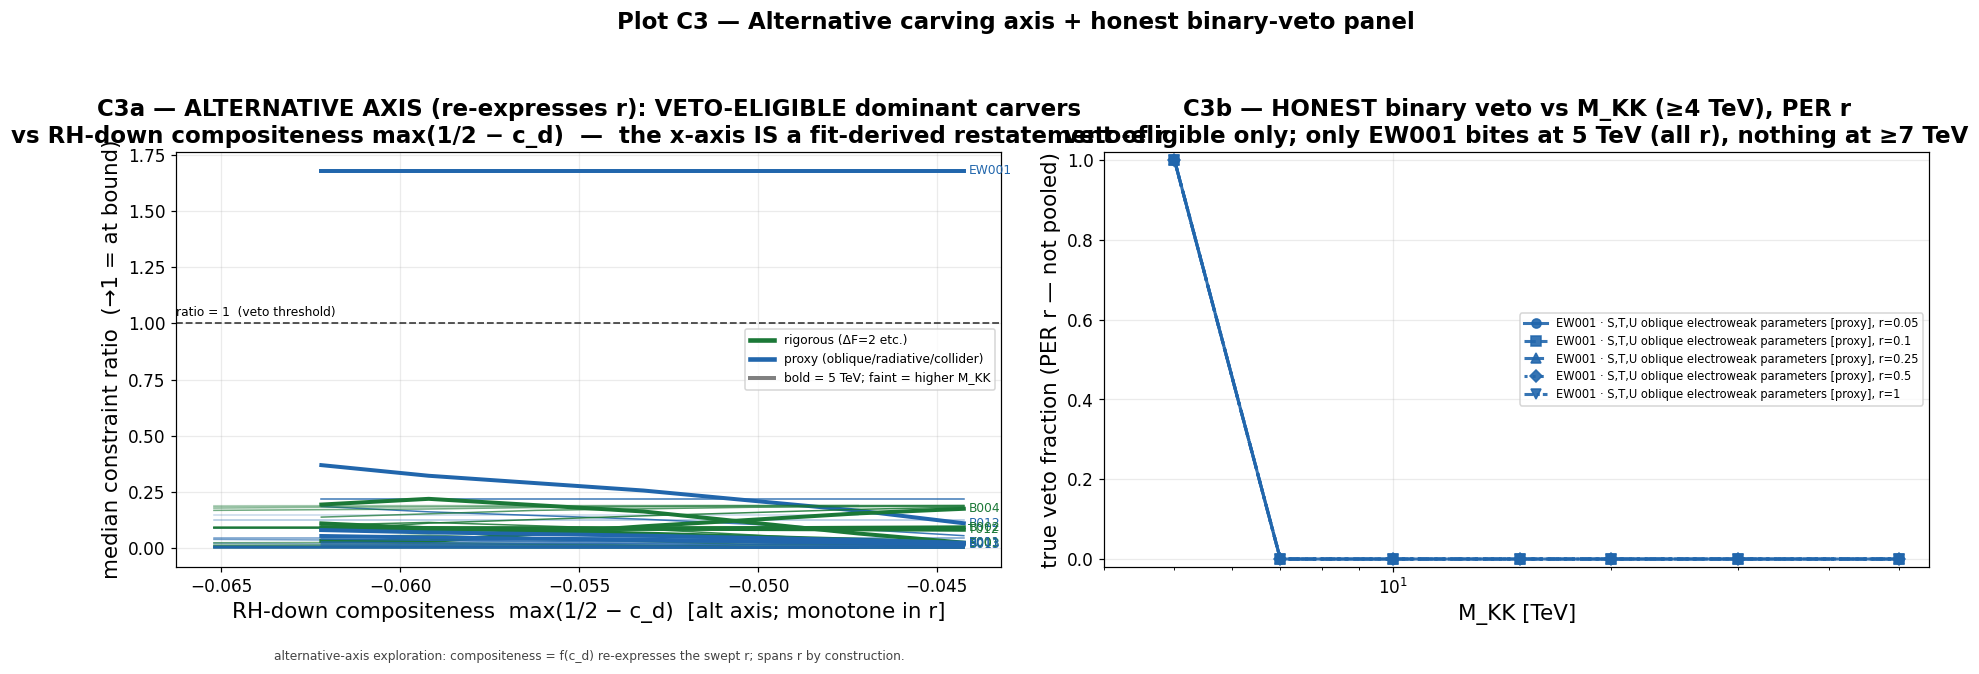

In [18]:
# RH-down compositeness axis on the full frame d
d["rh_down_comp"] = (0.5 - d[["cd1", "cd2", "cd3"]]).max(axis=1)
# bin it
d["rh_bin"] = pd.cut(d["rh_down_comp"], bins=np.linspace(d.rh_down_comp.min(),
                     d.rh_down_comp.max(), 9))
def carving_table_binned(frame, bincol):
    rows = []
    for xv, cell0 in frame.groupby(bincol, observed=True):
        xc = xv.mid
        for mkk in MKK_KEEP:
            cell = cell0[cell0.M_KK == mkk]
            if len(cell) == 0:
                continue
            for cid in ALLOWLIST:
                ev = cell[cell[EVAL_COLS[cid]]]
                if len(ev) == 0:
                    continue
                r = ev[RATIO_COLS[cid]].dropna()
                if len(r) == 0:
                    continue
                rows.append({"x": float(xc), "M_KK": mkk, "cid": cid,
                             "tag": TAG[cid], "median_ratio": float(r.median())})
    return pd.DataFrame(rows)

carve_rh = carving_table_binned(d, "rh_bin")

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
# left: alternative-X carving (dominant ids reused)
carving_panel(axes[0], carve_rh, dom_ids,
              "C3a — ALTERNATIVE AXIS (re-expresses r): VETO-ELIGIBLE dominant carvers\n"
              "vs RH-down compositeness max(1/2 − c_d)  —  the x-axis IS a fit-derived "
              "restatement of r",
              "RH-down compositeness  max(1/2 − c_d)  [alt axis; monotone in r]", xlog=False)
# Make explicit this is the alternative-axis exploration, NOT a single-scale result:
# the compositeness axis is derived from c_d, which is set by the same fit that r drives,
# so it spans r by construction (not a pooling artifact).
axes[0].text(0.5, -0.20, "alternative-axis exploration: compositeness = f(c_d) "
             "re-expresses the swept r; spans r by construction.",
             transform=axes[0].transAxes, ha="center", va="top",
             fontsize=8, color="#444444")

# right: honest binary veto fraction vs M_KK, shown PER r (NOT pooled). Binary veto is
# both M_KK- and r-dependent, so pooling over r would be silent scale-mixing. We draw one
# line per r for each veto-eligible constraint (HARD & rigorous/proxy = the harness
# survives_inclusive rule) that vetoes anything; r is encoded by line style/marker.
ax = axes[1]
rstyles = {rv: st for rv, st in zip(
    R_VALS, ["-", "--", "-.", ":", (0, (3, 1, 1, 1))][: len(R_VALS)])}
rmark = {rv: mk for rv, mk in zip(R_VALS, ["o", "s", "^", "D", "v", "P", "X"][: len(R_VALS)])}
# which veto-eligible constraints ever veto (any r, any M_KK)?
veto_cids = []
for cid in VETO_ELIGIBLE:
    mx = 0.0
    for mkk in MKK_KEEP:
        for rv in R_VALS:
            cell = d[(d.M_KK == mkk) & (d.r == rv) & (d[EVAL_COLS[cid]])]
            if len(cell):
                mx = max(mx, (~cell[f"{cid}__pass"]).mean())
    if mx > 0:
        veto_cids.append(cid)
plotted = 0
for cid in veto_cids:
    for rv in R_VALS:
        fr = []
        for mkk in MKK_KEEP:
            cell = d[(d.M_KK == mkk) & (d.r == rv) & (d[EVAL_COLS[cid]])]
            fr.append((~cell[f"{cid}__pass"]).mean() if len(cell) else 0.0)
        ax.plot([m / 1000 for m in MKK_KEEP], fr, marker=rmark[rv], ls=rstyles[rv],
                color=TAG_COLOR[TAG[cid]], lw=2.0, ms=6, alpha=0.9,
                label=f"{cid} · {OBSERVABLE[cid]} [{TAG[cid]}], r={rv:g}")
        plotted += 1
ax.set_xscale("log")
ax.set_xlabel("M_KK [TeV]"); ax.set_ylabel("true veto fraction (PER r — not pooled)")
ax.set_xlim(4.0, 55.0)  # floor every M_KK axis at the 4 TeV hard cut
ax.set_ylim(-0.02, 1.02)
ax.set_title("C3b — HONEST binary veto vs M_KK (≥4 TeV), PER r\n"
             "veto-eligible only; only EW001 bites at 5 TeV (all r), nothing at ≥7 TeV")
if plotted:
    ax.legend(fontsize=7.5, loc="center right", ncols=1)
else:
    ax.text(0.5, 0.5, "NO veto-eligible constraint vetoes any point at M_KK ≥ 5 TeV\n"
            "(all rigorous ΔF=2 + proxy bounds already satisfied)",
            ha="center", va="center", transform=ax.transAxes, fontsize=13,
            bbox=dict(boxstyle="round", fc="#ffeeee"))
fig.suptitle("Plot C3 — Alternative carving axis + honest binary-veto panel",
             fontsize=15, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(os.path.join(FIGDIR, "C3_alt_axis_and_honest_veto.png"), bbox_inches="tight")
plt.show()

## Summary of findings

- **Plot A (Yukawas).** We use the **fitted/physical** 3×3 (recomputed deterministically
  for a stratified ≥5 TeV subsample; verified to reproduce stored `c_Q`/singular values),
  because that is what the constraints actually see; the **input-anarchic** prior is shown
  alongside for contrast (A4). The fitted texture is strongly hierarchical: a bright
  (3,3)≈top entry, suppressed first row/column — i.e. anarchic O(1) input is reshaped by
  the geometry into a realistic CKM texture. The fitted Yukawa is `M_KK`-independent and
  varies mainly with `r`.
- **Plot B (bulk c).** Third-generation `c_Q`, `c_u`, `c_d` localize near/below 1/2
  (IR-localized heavy quarks); generations 1–2 sit well above 1/2 (UV-localized). The
  localization is set by `r` + mass/CKM targets and is essentially `M_KK`-independent.
- **Plot C (carving).** Chosen `X = r`; also tried RH-down compositeness `max(1/2−c_d)`
  and Yukawa-anarchy `max|Y_q|`. Among **veto-eligible** constraints (HARD & rigorous/
  proxy), the residual pressure above 4 TeV comes from the proxy `EW001` (oblique S,T,U)
  and the `B011/B012` b→sγ family, with the rigorous ΔF=2 set (`K001` ε_K, `B003` Δm_s,
  `B004` φ_s) next; all rise with `r`. **Important caveat surfaced by the data:** several
  high-`ratio` entries do **NOT veto**: `T010` (Z→bb), `T001`, `T002`, `T011` are
  `partial` **&** HARD — non-vetoing because their matching is *incomplete* (`partial`),
  not because they are soft; `B034`, `EW003`, and the placeholder-`ratio=1` nonleptonic/
  EDM proxies (`C003/K003/K013/B032/B033`, `E004–E009`) are `partial` **&** INFO/SOFT.
  All are NEEDS-HUMAN-PHYSICS and isolated into the C1c "advisory-only" panel so their
  ratio is not mistaken for a real bound.
- **Honest ≥4 TeV limitation.** Above the 4 TeV floor the carving is genuinely **thin**:
  strict (rigorous) survival is already 100% at ≥5 TeV (ΔF=2 reach ~1–3 TeV); inclusive
  survival is 0% at 5 TeV → 100% at ≥7 TeV, i.e. the **sole** real veto past 4 TeV is
  `EW001` at 5 TeV, and **nothing** excludes at ≥7 TeV. The `ratio` view (C1/C2) surfaces
  the residual structure that the binary-veto view (C3b) cannot.
print("notebook complete — figures written to", FIGDIR)